In [183]:
!pip -q install requests pandas numpy matplotlib

In [184]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [185]:
cities = {
    "Kolkata": {
        "latitude": 22.5726,
        "longitude": 88.3639
    },

    "Delhi": {
        "latitude": 28.6139,
        "longitude": 77.2090
    },

    "Mumbai": {
        "latitude": 19.0760,
        "longitude": 72.8777
    },

    "Ahmedabad": {
        "latitude": 23.0225,
        "longitude": 72.5714
    },

    "Srinagar": {
        "latitude": 34.0837,
        "longitude": 74.7973
    }
}

cities

{'Kolkata': {'latitude': 22.5726, 'longitude': 88.3639},
 'Delhi': {'latitude': 28.6139, 'longitude': 77.209},
 'Mumbai': {'latitude': 19.076, 'longitude': 72.8777},
 'Ahmedabad': {'latitude': 23.0225, 'longitude': 72.5714},
 'Srinagar': {'latitude': 34.0837, 'longitude': 74.7973}}

In [186]:
def get_nasa_power_data(
    city,
    latitude,
    longitude,
    start_date="20200101",
    end_date="20241231"
):

    url = "https://power.larc.nasa.gov/api/temporal/hourly/point"

    parameters = [
        "T2M",
        "RH2M",
        "WS10M",
        "ALLSKY_SFC_SW_DWN",
        "PS",
        "PRECTOTCORR"
    ]

    params = {
        "parameters": ",".join(parameters),
        "community": "RE",
        "longitude": longitude,
        "latitude": latitude,
        "start": start_date,
        "end": end_date,
        "format": "JSON",
        "time-standard": "UTC"
    }

    response = requests.get(
        url,
        params=params,
        timeout=120
    )

    response.raise_for_status()

    data = response.json()

    # NASA POWER stores parameters as:
    # data["properties"]["parameter"]["T2M"]["2020010100"] = value

    parameter_data = data["properties"]["parameter"]

    # Get all timestamps from the first parameter
    timestamps = list(
        parameter_data["T2M"].keys()
    )

    rows = []

    for timestamp in timestamps:

        row = {
            "datetime": timestamp,
            "T2M": parameter_data["T2M"].get(timestamp, np.nan),
            "RH2M": parameter_data["RH2M"].get(timestamp, np.nan),
            "WS10M": parameter_data["WS10M"].get(timestamp, np.nan),
            "ALLSKY_SFC_SW_DWN": parameter_data[
                "ALLSKY_SFC_SW_DWN"
            ].get(timestamp, np.nan),
            "PS": parameter_data["PS"].get(timestamp, np.nan),
            "PRECTOTCORR": parameter_data[
                "PRECTOTCORR"
            ].get(timestamp, np.nan)
        }

        rows.append(row)

    df = pd.DataFrame(rows)

    # Convert NASA POWER timestamp
    df["datetime"] = pd.to_datetime(
        df["datetime"],
        format="%Y%m%d%H"
    )

    # Add location information
    df["city"] = city
    df["latitude"] = latitude
    df["longitude"] = longitude

    return df

In [187]:
kolkata_test = get_nasa_power_data(
    city="Kolkata",
    latitude=22.5726,
    longitude=88.3639,
    start_date="20200501",
    end_date="20200502"
)

print("Rows:", len(kolkata_test))
print("Columns:")
print(kolkata_test.columns.tolist())

Rows: 48
Columns:
['datetime', 'T2M', 'RH2M', 'WS10M', 'ALLSKY_SFC_SW_DWN', 'PS', 'PRECTOTCORR', 'city', 'latitude', 'longitude']


In [188]:
kolkata_test.head()

,datetime,T2M,RH2M,WS10M,ALLSKY_SFC_SW_DWN,PS,PRECTOTCORR,city,latitude,longitude
0,2020-05-01 00:00:00,26.18,89.74,2.79,83.82,100.88,0.70,Kolkata,22.5726,88.3639
1,2020-05-01 01:00:00,28.07,78.23,3.46,236.40,100.93,0.64,Kolkata,22.5726,88.3639
2,2020-05-01 02:00:00,30.05,65.54,3.28,393.50,100.96,0.58,Kolkata,22.5726,88.3639
3,2020-05-01 03:00:00,31.49,58.59,2.66,583.65,100.96,1.57,Kolkata,22.5726,88.3639
4,2020-05-01 04:00:00,32.36,55.69,2.29,749.03,100.93,1.71,Kolkata,22.5726,88.3639


In [189]:
print(kolkata_test.shape)
print(kolkata_test.head())
print(kolkata_test.tail())

(48, 10)
             datetime    T2M   RH2M  WS10M  ALLSKY_SFC_SW_DWN      PS  \
0 2020-05-01 00:00:00  26.18  89.74   2.79              83.82  100.88   
1 2020-05-01 01:00:00  28.07  78.23   3.46             236.40  100.93   
2 2020-05-01 02:00:00  30.05  65.54   3.28             393.50  100.96   
3 2020-05-01 03:00:00  31.49  58.59   2.66             583.65  100.96   
4 2020-05-01 04:00:00  32.36  55.69   2.29             749.03  100.93   

   PRECTOTCORR     city  latitude  longitude  
0         0.70  Kolkata   22.5726    88.3639  
1         0.64  Kolkata   22.5726    88.3639  
2         0.58  Kolkata   22.5726    88.3639  
3         1.57  Kolkata   22.5726    88.3639  
4         1.71  Kolkata   22.5726    88.3639  
              datetime    T2M   RH2M  WS10M  ALLSKY_SFC_SW_DWN      PS  \
43 2020-05-02 19:00:00  25.21  91.17   1.92               0.00  100.57   
44 2020-05-02 20:00:00  24.94  92.83   1.79               0.00  100.55   
45 2020-05-02 21:00:00  24.74  93.89   1.59     

In [190]:
# ============================================================
# HEATGUARD - Download 2020-2024 Heat Season Data
# ============================================================

all_city_data = []

for city, location in cities.items():

    print(f"\nDownloading {city}...")

    try:

        # April 1 to June 30 for each year
        yearly_data = []

        for year in range(2020, 2025):

            start_date = f"{year}0401"
            end_date = f"{year}0630"

            print(
                f"  → {year}: {start_date} to {end_date}"
            )

            df_year = get_nasa_power_data(
                city=city,
                latitude=location["latitude"],
                longitude=location["longitude"],
                start_date=start_date,
                end_date=end_date
            )

            yearly_data.append(df_year)

            print(
                f"     {len(df_year):,} rows"
            )

            time.sleep(1)

        # Combine all years for this city
        df_city = pd.concat(
            yearly_data,
            ignore_index=True
        )

        all_city_data.append(df_city)

        print(
            f"  ✓ {city} complete: "
            f"{len(df_city):,} rows"
        )

    except Exception as e:

        print(
            f"  ✗ Error downloading {city}: {e}"
        )


  → 2020: 20200401 to 20200630
     2,184 rows
  → 2021: 20210401 to 20210630
     2,184 rows
  → 2022: 20220401 to 20220630
     2,184 rows
  → 2023: 20230401 to 20230630
     2,184 rows
  → 2024: 20240401 to 20240630
     2,184 rows
  ✓ Kolkata complete: 10,920 rows

  → 2020: 20200401 to 20200630
     2,184 rows
  → 2021: 20210401 to 20210630
     2,184 rows
  → 2022: 20220401 to 20220630
     2,184 rows
  → 2023: 20230401 to 20230630
     2,184 rows
  → 2024: 20240401 to 20240630
     2,184 rows
  ✓ Delhi complete: 10,920 rows

  → 2020: 20200401 to 20200630
     2,184 rows
  → 2021: 20210401 to 20210630
     2,184 rows
  → 2022: 20220401 to 20220630
     2,184 rows
  → 2023: 20230401 to 20230630
     2,184 rows
  → 2024: 20240401 to 20240630
     2,184 rows
  ✓ Mumbai complete: 10,920 rows

  → 2020: 20200401 to 20200630
     2,184 rows
  → 2021: 20210401 to 20210630
     2,184 rows
  → 2022: 20220401 to 20220630
     2,184 rows
  → 2023: 20230401 to 20230630
     2,184 rows
  → 

In [191]:
# Combine all cities

weather_raw = pd.concat(
    all_city_data,
    ignore_index=True
)

print(
    "Total observations:",
    f"{len(weather_raw):,}"
)

print(
    "\nDataset shape:",
    weather_raw.shape
)

Total observations: 54,600

Dataset shape: (54600, 10)


In [192]:
weather_raw = weather_raw.rename(
    columns={
        "T2M": "temperature_c",
        "RH2M": "relative_humidity",
        "WS10M": "wind_speed_ms",
        "ALLSKY_SFC_SW_DWN": "solar_radiation",
        "PS": "surface_pressure_kpa",
        "PRECTOTCORR": "precipitation_mm"
    }
)

weather_raw.head()

,datetime,temperature_c,relative_humidity,wind_speed_ms,solar_radiation,surface_pressure_kpa,precipitation_mm,city,latitude,longitude
0,2020-04-01 00:00:00,22.37,60.18,1.89,50.75,100.89,0.0,Kolkata,22.5726,88.3639
1,2020-04-01 01:00:00,24.94,49.00,3.02,252.65,100.97,0.0,Kolkata,22.5726,88.3639
2,2020-04-01 02:00:00,28.56,40.94,2.98,481.45,101.02,0.0,Kolkata,22.5726,88.3639
3,2020-04-01 03:00:00,33.46,28.64,2.88,686.97,101.02,0.0,Kolkata,22.5726,88.3639
4,2020-04-01 04:00:00,35.76,25.63,3.14,841.15,100.99,0.0,Kolkata,22.5726,88.3639


In [193]:
weather_raw = weather_raw[
    [
        "datetime",
        "city",
        "latitude",
        "longitude",
        "temperature_c",
        "relative_humidity",
        "wind_speed_ms",
        "solar_radiation",
        "surface_pressure_kpa",
        "precipitation_mm"
    ]
]

weather_raw.head()

,datetime,city,latitude,longitude,temperature_c,relative_humidity,wind_speed_ms,solar_radiation,surface_pressure_kpa,precipitation_mm
0,2020-04-01 00:00:00,Kolkata,22.5726,88.3639,22.37,60.18,1.89,50.75,100.89,0.0
1,2020-04-01 01:00:00,Kolkata,22.5726,88.3639,24.94,49.00,3.02,252.65,100.97,0.0
2,2020-04-01 02:00:00,Kolkata,22.5726,88.3639,28.56,40.94,2.98,481.45,101.02,0.0
3,2020-04-01 03:00:00,Kolkata,22.5726,88.3639,33.46,28.64,2.88,686.97,101.02,0.0
4,2020-04-01 04:00:00,Kolkata,22.5726,88.3639,35.76,25.63,3.14,841.15,100.99,0.0


In [194]:
print("=" * 60)
print("HEATGUARD DATASET VALIDATION")
print("=" * 60)

print("\nDataset shape:")
print(weather_raw.shape)

print("\nObservations by city:")
print(weather_raw["city"].value_counts())

print("\nMissing values:")
print(weather_raw.isna().sum())

print("\nDuplicate rows:")
print(weather_raw.duplicated().sum())

print("\nDate range:")
print(weather_raw["datetime"].min())
print(weather_raw["datetime"].max())

print("\nTemperature:")
print(
    weather_raw["temperature_c"].describe()
)

print("\nRelative Humidity:")
print(
    weather_raw["relative_humidity"].describe()
)

print("\nWind Speed:")
print(
    weather_raw["wind_speed_ms"].describe()
)

HEATGUARD DATASET VALIDATION

Dataset shape:
(54600, 10)

Observations by city:
city
Kolkata      10920
Delhi        10920
Mumbai       10920
Ahmedabad    10920
Srinagar     10920
Name: count, dtype: int64

Missing values:
datetime                0
city                    0
latitude                0
longitude               0
temperature_c           0
relative_humidity       0
wind_speed_ms           0
solar_radiation         0
surface_pressure_kpa    0
precipitation_mm        0
dtype: int64

Duplicate rows:
0

Date range:
2020-04-01 00:00:00
2024-06-30 23:00:00

Temperature:
count    54600.000000
mean        28.100267
std          9.609167
min         -6.880000
25%         25.330000
50%         29.150000
75%         34.600000
max         48.500000
Name: temperature_c, dtype: float64

Relative Humidity:
count    54600.000000
mean        53.334918
std         25.680573
min          2.400000
25%         30.810000
50%         53.570000
75%         75.520000
max        100.000000
Name: rela

In [195]:
# ============================================================
# HEATGUARD - DATA CLEANING
# ============================================================

# Make a copy so we preserve the raw dataset
weather = weather_raw.copy()

# Ensure datetime is correctly formatted
weather["datetime"] = pd.to_datetime(
    weather["datetime"]
)

# Sort chronologically
weather = weather.sort_values(
    ["city", "datetime"]
).reset_index(drop=True)

# Convert numeric columns
numeric_columns = [
    "temperature_c",
    "relative_humidity",
    "wind_speed_ms",
    "solar_radiation",
    "surface_pressure_kpa",
    "precipitation_mm"
]

for col in numeric_columns:
    weather[col] = pd.to_numeric(
        weather[col],
        errors="coerce"
    )

# Remove physically impossible values
weather.loc[
    (weather["relative_humidity"] < 0) |
    (weather["relative_humidity"] > 100),
    "relative_humidity"
] = np.nan

weather.loc[
    weather["wind_speed_ms"] < 0,
    "wind_speed_ms"
] = np.nan

weather.loc[
    weather["solar_radiation"] < 0,
    "solar_radiation"
] = np.nan

# Interpolate small gaps within each city
weather[numeric_columns] = (
    weather
    .groupby("city")[numeric_columns]
    .transform(
        lambda x: x.interpolate(
            limit=3
        )
    )
)

print("Cleaning complete.")
print("Shape:", weather.shape)
print("Missing values:")
print(weather.isna().sum())

Cleaning complete.
Shape: (54600, 10)
Missing values:
datetime                0
city                    0
latitude                0
longitude               0
temperature_c           0
relative_humidity       0
wind_speed_ms           0
solar_radiation         0
surface_pressure_kpa    0
precipitation_mm        0
dtype: int64


In [196]:
# ============================================================
# TIME FEATURES
# ============================================================

weather["date"] = weather["datetime"].dt.date

weather["year"] = weather["datetime"].dt.year
weather["month"] = weather["datetime"].dt.month
weather["day"] = weather["datetime"].dt.day
weather["hour"] = weather["datetime"].dt.hour

# Day of year
weather["day_of_year"] = (
    weather["datetime"].dt.dayofyear
)

# Is daytime?
weather["is_daytime"] = (
    (weather["hour"] >= 6) &
    (weather["hour"] < 18)
).astype(int)

# Is nighttime?
weather["is_night"] = (
    ~weather["is_daytime"].astype(bool)
).astype(int)

weather.head()

,datetime,city,latitude,longitude,temperature_c,relative_humidity,wind_speed_ms,solar_radiation,surface_pressure_kpa,precipitation_mm,date,year,month,day,hour,day_of_year,is_daytime,is_night
0,2020-04-01 00:00:00,Ahmedabad,23.0225,72.5714,20.98,65.10,2.52,0.00,100.55,0.0,2020-04-01,2020,4,1,0,92,0,1
1,2020-04-01 01:00:00,Ahmedabad,23.0225,72.5714,21.72,62.94,3.15,45.90,100.63,0.0,2020-04-01,2020,4,1,1,92,0,1
2,2020-04-01 02:00:00,Ahmedabad,23.0225,72.5714,24.42,54.55,4.28,252.57,100.72,0.0,2020-04-01,2020,4,1,2,92,0,1
3,2020-04-01 03:00:00,Ahmedabad,23.0225,72.5714,27.99,43.36,4.93,492.20,100.79,0.0,2020-04-01,2020,4,1,3,92,0,1
4,2020-04-01 04:00:00,Ahmedabad,23.0225,72.5714,31.91,31.48,4.67,706.97,100.80,0.0,2020-04-01,2020,4,1,4,92,0,1


In [197]:
# ============================================================
# HEAT INDEX
# ============================================================

def calculate_heat_index(T, RH):
    """
    Calculate Heat Index in Celsius.

    T  = air temperature in Celsius
    RH = relative humidity in %
    """

    T_f = T * 9/5 + 32

    # Simple approximation for lower temperatures
    HI_f = 0.5 * (
        T_f +
        61.0 +
        ((T_f - 68.0) * 1.2) +
        (RH * 0.094)
    )

    # Rothfusz regression
    rothfusz = (
        -42.379
        + 2.04901523 * T_f
        + 10.14333127 * RH
        - 0.22475541 * T_f * RH
        - 0.00683783 * T_f**2
        - 0.05481717 * RH**2
        + 0.00122874 * T_f**2 * RH
        + 0.00085282 * T_f * RH**2
        - 0.00000199 * T_f**2 * RH**2
    )

    # Apply Rothfusz primarily where HI is applicable
    use_rothfusz = (
        (T_f >= 80) &
        (RH >= 40)
    )

    HI_f = np.where(
        use_rothfusz,
        rothfusz,
        HI_f
    )

    HI_c = (
        HI_f - 32
    ) * 5/9

    return HI_c


weather["heat_index_c"] = calculate_heat_index(
    weather["temperature_c"],
    weather["relative_humidity"]
)

weather[
    [
        "temperature_c",
        "relative_humidity",
        "heat_index_c"
    ]
].head(10)

,temperature_c,relative_humidity,heat_index_c
0,20.98,65.10,20.833389
1,21.72,62.94,21.590989
2,24.42,54.55,24.341917
3,27.99,43.36,27.894470
4,31.91,31.48,31.978533
5,35.00,24.62,35.198411
6,36.89,21.48,37.195422
7,38.06,19.42,38.428633
8,38.67,17.93,39.060728
9,38.73,17.04,39.103489


In [198]:
# ============================================================
# APPROXIMATE MEAN RADIANT TEMPERATURE
# ============================================================

def estimate_mrt(
    air_temp,
    solar_radiation
):
    """
    Approximate mean radiant temperature from
    air temperature and incoming shortwave radiation.

    This is a prototype approximation.

    air_temp: °C
    solar_radiation: W/m²
    """

    # Solar heating contribution
    solar_effect = (
        0.02 *
        np.sqrt(
            np.maximum(
                solar_radiation,
                0
            )
        )
    )

    mrt = (
        air_temp +
        solar_effect
    )

    return mrt


weather["mrt_c"] = estimate_mrt(
    weather["temperature_c"],
    weather["solar_radiation"]
)

weather[
    [
        "temperature_c",
        "solar_radiation",
        "mrt_c"
    ]
].head(10)

,temperature_c,solar_radiation,mrt_c
0,20.98,0.00,20.980000
1,21.72,45.90,21.855499
2,24.42,252.57,24.737849
3,27.99,492.20,28.433712
4,31.91,706.97,32.441778
5,35.00,871.00,35.590254
6,36.89,961.78,37.510252
7,38.06,1003.65,38.693609
8,38.67,946.50,39.285305
9,38.73,800.80,39.295968


In [199]:
!pip -q install pythermalcomfort

In [200]:
from pythermalcomfort.models import utci

In [201]:
# ============================================================
# UTCI
# ============================================================

def calculate_utci_row(row):

    try:

        result = utci(
            tdb=row["temperature_c"],
            tr=row["mrt_c"],
            v=row["wind_speed_ms"],
            rh=row["relative_humidity"],
            limit_inputs=False
        )

        return float(
            result.utci
        )

    except Exception:
        return np.nan


weather["utci_c"] = weather.apply(
    calculate_utci_row,
    axis=1
)

print(
    weather[
        [
            "temperature_c",
            "relative_humidity",
            "wind_speed_ms",
            "mrt_c",
            "utci_c"
        ]
    ].head(20)
)

    temperature_c  relative_humidity  wind_speed_ms      mrt_c  utci_c
0           20.98              65.10           2.52  20.980000    19.0
1           21.72              62.94           3.15  21.855499    18.8
2           24.42              54.55           4.28  24.737849    20.3
3           27.99              43.36           4.93  28.433712    24.0
4           31.91              31.48           4.67  32.441778    28.9
5           35.00              24.62           4.06  35.590254    33.1
6           36.89              21.48           4.00  37.510252    35.6
7           38.06              19.42           4.21  38.693609    37.0
8           38.67              17.93           4.51  39.285305    37.7
9           38.73              17.04           4.89  39.295968    37.7
10          38.24              16.68           5.15  38.729400    37.0
11          37.17              16.95           5.24  37.550668    35.5
12          35.18              18.46           4.22  35.408998    32.9
13    

In [202]:
# ============================================================
# UTCI CATEGORY
# ============================================================

def utci_category(utci_value):

    if pd.isna(utci_value):
        return "Unknown"

    if utci_value < 9:
        return "No Thermal Stress"

    elif utci_value < 26:
        return "Moderate Cold Stress / Comfortable"

    elif utci_value < 32:
        return "Moderate Heat Stress"

    elif utci_value < 38:
        return "Strong Heat Stress"

    elif utci_value < 46:
        return "Very Strong Heat Stress"

    else:
        return "Extreme Heat Stress"


weather["utci_category"] = (
    weather["utci_c"]
    .apply(utci_category)
)

weather[
    [
        "datetime",
        "city",
        "temperature_c",
        "utci_c",
        "utci_category"
    ]
].head(20)

,datetime,city,temperature_c,utci_c,utci_category
0,2020-04-01 00:00:00,Ahmedabad,20.98,19.0,Moderate Cold Stress / Comfortable
1,2020-04-01 01:00:00,Ahmedabad,21.72,18.8,Moderate Cold Stress / Comfortable
2,2020-04-01 02:00:00,Ahmedabad,24.42,20.3,Moderate Cold Stress / Comfortable
3,2020-04-01 03:00:00,Ahmedabad,27.99,24.0,Moderate Cold Stress / Comfortable
4,2020-04-01 04:00:00,Ahmedabad,31.91,28.9,Moderate Heat Stress
5,2020-04-01 05:00:00,Ahmedabad,35.00,33.1,Strong Heat Stress
6,2020-04-01 06:00:00,Ahmedabad,36.89,35.6,Strong Heat Stress
7,2020-04-01 07:00:00,Ahmedabad,38.06,37.0,Strong Heat Stress
8,2020-04-01 08:00:00,Ahmedabad,38.67,37.7,Strong Heat Stress
9,2020-04-01 09:00:00,Ahmedabad,38.73,37.7,Strong Heat Stress


In [203]:
# ============================================================
# APPROXIMATE WBGT
# ============================================================

def estimate_wet_bulb(
    temperature,
    relative_humidity
):
    """
    Stull approximation for wet-bulb temperature.
    """

    rh = np.clip(
        relative_humidity,
        1,
        100
    )

    tw = (
        temperature *
        np.arctan(
            0.151977 *
            np.sqrt(rh + 8.313659)
        )
        +
        np.arctan(
            temperature + rh
        )
        -
        np.arctan(
            rh - 1.676331
        )
        +
        0.00391838 *
        rh ** 1.5 *
        np.arctan(
            0.023101 *
            rh
        )
        -
        4.686035
    )

    return tw


weather["wet_bulb_c"] = estimate_wet_bulb(
    weather["temperature_c"],
    weather["relative_humidity"]
)

# Approximate globe temperature
weather["globe_temp_c"] = (
    weather["temperature_c"] +
    0.03 *
    np.sqrt(
        np.maximum(
            weather["solar_radiation"],
            0
        )
    )
)

# Outdoor WBGT approximation
weather["wbgt_c"] = (
    0.7 * weather["wet_bulb_c"] +
    0.2 * weather["globe_temp_c"] +
    0.1 * weather["temperature_c"]
)

weather[
    [
        "temperature_c",
        "relative_humidity",
        "wet_bulb_c",
        "globe_temp_c",
        "wbgt_c"
    ]
].head(10)

,temperature_c,relative_humidity,wet_bulb_c,globe_temp_c,wbgt_c
0,20.98,65.10,16.558992,20.980000,17.885295
1,21.72,62.94,16.949571,21.923249,18.421349
2,24.42,54.55,18.184039,24.896774,20.150182
3,27.99,43.36,19.423056,28.655567,22.126253
4,31.91,31.48,20.156283,32.707667,23.841931
5,35.00,24.62,20.691024,35.885381,25.160793
6,36.89,21.48,21.073222,37.820377,26.004331
7,38.06,19.42,21.183107,39.010413,26.436258
8,38.67,17.93,21.055860,39.592957,26.524693
9,38.73,17.04,20.762217,39.578952,26.322342


In [204]:
# ============================================================
# THERMAL STRESS SCORE
# ============================================================

def normalize_utci(utci):
    return np.clip(
        (utci - 26) / (46 - 26) * 100,
        0,
        100
    )


def normalize_wbgt(wbgt):
    return np.clip(
        (wbgt - 25) / (35 - 25) * 100,
        0,
        100
    )


def normalize_heat_index(hi):
    return np.clip(
        (hi - 27) / (50 - 27) * 100,
        0,
        100
    )


weather["utci_score"] = normalize_utci(
    weather["utci_c"]
)

weather["wbgt_score"] = normalize_wbgt(
    weather["wbgt_c"]
)

weather["heat_index_score"] = normalize_heat_index(
    weather["heat_index_c"]
)

In [205]:
# ============================================================
# HUMAN THERMAL STRESS INDEX
# ============================================================

weather["human_thermal_stress_index"] = (
    0.50 * weather["utci_score"] +
    0.30 * weather["wbgt_score"] +
    0.20 * weather["heat_index_score"]
)

weather["human_thermal_stress_index"] = (
    np.clip(
        weather["human_thermal_stress_index"],
        0,
        100
    )
)

weather[
    [
        "datetime",
        "city",
        "utci_c",
        "wbgt_c",
        "heat_index_c",
        "human_thermal_stress_index"
    ]
].head(20)

,datetime,city,utci_c,wbgt_c,heat_index_c,human_thermal_stress_index
0,2020-04-01 00:00:00,Ahmedabad,19.0,17.885295,20.833389,0.000000
1,2020-04-01 01:00:00,Ahmedabad,18.8,18.421349,21.590989,0.000000
2,2020-04-01 02:00:00,Ahmedabad,20.3,20.150182,24.341917,0.000000
3,2020-04-01 03:00:00,Ahmedabad,24.0,22.126253,27.894470,0.777800
4,2020-04-01 04:00:00,Ahmedabad,28.9,23.841931,31.978533,11.579159
5,2020-04-01 05:00:00,Ahmedabad,33.1,25.160793,35.198411,25.361433
6,2020-04-01 06:00:00,Ahmedabad,35.6,26.004331,37.195422,35.878578
7,2020-04-01 07:00:00,Ahmedabad,37.0,26.436258,38.428633,41.746715
8,2020-04-01 08:00:00,Ahmedabad,37.7,26.524693,39.060728,44.311670
9,2020-04-01 09:00:00,Ahmedabad,37.7,26.322342,39.103489,43.741799


In [206]:
# ============================================================
# RISK CLASSIFICATION
# ============================================================

def risk_category(score):

    if pd.isna(score):
        return "Unknown"

    if score < 25:
        return "LOW"

    elif score < 50:
        return "MODERATE"

    elif score < 70:
        return "HIGH"

    elif score < 85:
        return "SEVERE"

    else:
        return "EXTREME"


weather["risk_category"] = (
    weather["human_thermal_stress_index"]
    .apply(risk_category)
)

weather[
    [
        "datetime",
        "city",
        "human_thermal_stress_index",
        "risk_category"
    ]
].head(20)

,datetime,city,human_thermal_stress_index,risk_category
0,2020-04-01 00:00:00,Ahmedabad,0.000000,LOW
1,2020-04-01 01:00:00,Ahmedabad,0.000000,LOW
2,2020-04-01 02:00:00,Ahmedabad,0.000000,LOW
3,2020-04-01 03:00:00,Ahmedabad,0.777800,LOW
4,2020-04-01 04:00:00,Ahmedabad,11.579159,LOW
5,2020-04-01 05:00:00,Ahmedabad,25.361433,MODERATE
6,2020-04-01 06:00:00,Ahmedabad,35.878578,MODERATE
7,2020-04-01 07:00:00,Ahmedabad,41.746715,MODERATE
8,2020-04-01 08:00:00,Ahmedabad,44.311670,MODERATE
9,2020-04-01 09:00:00,Ahmedabad,43.741799,MODERATE


In [207]:
# ============================================================
# DAILY THERMAL FEATURES
# ============================================================

daily = (
    weather
    .groupby(
        ["city", "latitude", "longitude", "date"],
        as_index=False
    )
    .agg(
        mean_temperature_c=(
            "temperature_c",
            "mean"
        ),

        max_temperature_c=(
            "temperature_c",
            "max"
        ),

        min_temperature_c=(
            "temperature_c",
            "min"
        ),

        mean_humidity=(
            "relative_humidity",
            "mean"
        ),

        max_humidity=(
            "relative_humidity",
            "max"
        ),

        mean_wind_speed=(
            "wind_speed_ms",
            "mean"
        ),

        max_solar_radiation=(
            "solar_radiation",
            "max"
        ),

        mean_utci_c=(
            "utci_c",
            "mean"
        ),

        max_utci_c=(
            "utci_c",
            "max"
        ),

        min_utci_c=(
            "utci_c",
            "min"
        ),

        mean_wbgt_c=(
            "wbgt_c",
            "mean"
        ),

        max_wbgt_c=(
            "wbgt_c",
            "max"
        ),

        max_heat_index_c=(
            "heat_index_c",
            "max"
        ),

        max_thermal_stress=(
            "human_thermal_stress_index",
            "max"
        ),

        mean_thermal_stress=(
            "human_thermal_stress_index",
            "mean"
        ),

        precipitation_mm=(
            "precipitation_mm",
            "sum"
        )
    )
)

daily.head()

,city,latitude,longitude,date,mean_temperature_c,max_temperature_c,min_temperature_c,mean_humidity,max_humidity,mean_wind_speed,max_solar_radiation,mean_utci_c,max_utci_c,min_utci_c,mean_wbgt_c,max_wbgt_c,max_heat_index_c,max_thermal_stress,mean_thermal_stress,precipitation_mm
0,Ahmedabad,23.0225,72.5714,2020-04-01,29.646667,38.73,20.98,31.005833,65.10,3.780000,1003.65,26.837500,37.7,18.1,21.328730,26.524693,39.103489,44.311670,13.048611,0.0
1,Ahmedabad,23.0225,72.5714,2020-04-02,30.282500,39.27,20.84,21.712917,37.76,2.296250,1006.67,27.795833,38.3,16.8,20.316819,25.067671,39.546044,41.723994,14.894132,0.0
2,Ahmedabad,23.0225,72.5714,2020-04-03,30.866250,40.72,21.47,19.607083,33.95,3.050417,1012.40,27.583333,39.7,15.3,20.300651,25.573490,41.103183,48.234109,16.114216,0.0
3,Ahmedabad,23.0225,72.5714,2020-04-04,31.323333,41.15,20.94,18.462500,33.98,2.962500,1016.70,28.550000,40.4,16.1,20.467242,25.929537,41.577750,51.439625,17.638934,0.0
4,Ahmedabad,23.0225,72.5714,2020-04-05,31.977500,41.16,22.07,17.380833,27.78,2.454167,1030.70,29.183333,40.1,17.8,20.834072,25.951702,41.593189,50.789695,18.114389,0.0


In [208]:
# ============================================================
# NIGHTTIME HEAT
# ============================================================

night_data = weather[
    weather["is_night"] == 1
].copy()

night_daily = (
    night_data
    .groupby(
        ["city", "date"]
    )
    .agg(
        nighttime_min_temperature_c=(
            "temperature_c",
            "min"
        ),

        nighttime_mean_utci_c=(
            "utci_c",
            "mean"
        ),

        nighttime_max_utci_c=(
            "utci_c",
            "max"
        )
    )
    .reset_index()
)

daily = daily.merge(
    night_daily,
    on=["city", "date"],
    how="left"
)

daily.head()

,city,latitude,longitude,date,mean_temperature_c,max_temperature_c,min_temperature_c,mean_humidity,max_humidity,mean_wind_speed,...,min_utci_c,mean_wbgt_c,max_wbgt_c,max_heat_index_c,max_thermal_stress,mean_thermal_stress,precipitation_mm,nighttime_min_temperature_c,nighttime_mean_utci_c,nighttime_max_utci_c
0,Ahmedabad,23.0225,72.5714,2020-04-01,29.646667,38.73,20.98,31.005833,65.10,3.780000,...,18.1,21.328730,26.524693,39.103489,44.311670,13.048611,0.0,20.98,22.008333,33.1
1,Ahmedabad,23.0225,72.5714,2020-04-02,30.282500,39.27,20.84,21.712917,37.76,2.296250,...,16.8,20.316819,25.067671,39.546044,41.723994,14.894132,0.0,20.84,22.275000,34.5
2,Ahmedabad,23.0225,72.5714,2020-04-03,30.866250,40.72,21.47,19.607083,33.95,3.050417,...,15.3,20.300651,25.573490,41.103183,48.234109,16.114216,0.0,21.47,21.600000,35.9
3,Ahmedabad,23.0225,72.5714,2020-04-04,31.323333,41.15,20.94,18.462500,33.98,2.962500,...,16.1,20.467242,25.929537,41.577750,51.439625,17.638934,0.0,20.94,22.425000,35.8
4,Ahmedabad,23.0225,72.5714,2020-04-05,31.977500,41.16,22.07,17.380833,27.78,2.454167,...,17.8,20.834072,25.951702,41.593189,50.789695,18.114389,0.0,22.07,24.066667,37.5


In [209]:
# ============================================================
# ROLLING THERMAL STRESS
# ============================================================

daily["date"] = pd.to_datetime(
    daily["date"]
)

daily = daily.sort_values(
    ["city", "date"]
)

grouped = daily.groupby("city")

daily["utci_3day_mean"] = (
    grouped["mean_utci_c"]
    .transform(
        lambda x: x.rolling(
            3,
            min_periods=1
        ).mean()
    )
)

daily["utci_3day_max"] = (
    grouped["max_utci_c"]
    .transform(
        lambda x: x.rolling(
            3,
            min_periods=1
        ).max()
    )
)

daily["utci_5day_mean"] = (
    grouped["mean_utci_c"]
    .transform(
        lambda x: x.rolling(
            5,
            min_periods=1
        ).mean()
    )
)

daily["temperature_3day_mean"] = (
    grouped["mean_temperature_c"]
    .transform(
        lambda x: x.rolling(
            3,
            min_periods=1
        ).mean()
    )
)

daily["night_temp_3day_mean"] = (
    grouped["nighttime_min_temperature_c"]
    .transform(
        lambda x: x.rolling(
            3,
            min_periods=1
        ).mean()
    )
)

In [210]:
# ============================================================
# CONSECUTIVE HOT DAYS
# ============================================================

daily["hot_day"] = (
    daily["max_utci_c"] >= 32
).astype(int)

daily["hot_night"] = (
    daily["nighttime_min_temperature_c"] >= 25
).astype(int)


def consecutive_count(series):

    result = []
    count = 0

    for value in series:

        if value == 1:
            count += 1
        else:
            count = 0

        result.append(count)

    return result


daily["consecutive_hot_days"] = (
    daily
    .groupby("city")["hot_day"]
    .transform(consecutive_count)
)

daily["consecutive_hot_nights"] = (
    daily
    .groupby("city")["hot_night"]
    .transform(consecutive_count)
)

daily[
    [
        "city",
        "date",
        "max_utci_c",
        "hot_day",
        "consecutive_hot_days",
        "nighttime_min_temperature_c",
        "consecutive_hot_nights"
    ]
].tail(20)

,city,date,max_utci_c,hot_day,consecutive_hot_days,nighttime_min_temperature_c,consecutive_hot_nights
2255,Srinagar,2024-06-11,17.9,0,0,10.37,0
2256,Srinagar,2024-06-12,18.7,0,0,10.28,0
2257,Srinagar,2024-06-13,19.1,0,0,8.29,0
2258,Srinagar,2024-06-14,19.6,0,0,9.42,0
2259,Srinagar,2024-06-15,18.7,0,0,10.81,0
2260,Srinagar,2024-06-16,22.1,0,0,11.77,0
2261,Srinagar,2024-06-17,21.3,0,0,12.87,0
2262,Srinagar,2024-06-18,20.9,0,0,11.71,0
2263,Srinagar,2024-06-19,19.2,0,0,10.97,0
2264,Srinagar,2024-06-20,17.6,0,0,10.18,0


In [211]:
# ============================================================
# PERSISTENCE SCORE
# ============================================================

daily["persistence_score"] = np.clip(
    (
        daily["consecutive_hot_days"] / 5
    ) * 60
    +
    (
        daily["consecutive_hot_nights"] / 3
    ) * 40,
    0,
    100
)

In [212]:
# ============================================================
# FINAL ENVIRONMENTAL HEAT RISK
# ============================================================

utci_risk = np.clip(
    (
        daily["max_utci_c"] - 26
    ) / 20 * 100,
    0,
    100
)

night_risk = np.clip(
    (
        daily["nighttime_min_temperature_c"] - 20
    ) / 15 * 100,
    0,
    100
)

daily["environmental_heat_risk"] = (
    0.60 * utci_risk +
    0.25 * daily["persistence_score"] +
    0.15 * night_risk
)

daily["environmental_heat_risk"] = np.clip(
    daily["environmental_heat_risk"],
    0,
    100
)

daily["risk_category"] = (
    daily["environmental_heat_risk"]
    .apply(risk_category)
)

daily.head()

,city,latitude,longitude,date,mean_temperature_c,max_temperature_c,min_temperature_c,mean_humidity,max_humidity,mean_wind_speed,...,utci_5day_mean,temperature_3day_mean,night_temp_3day_mean,hot_day,hot_night,consecutive_hot_days,consecutive_hot_nights,persistence_score,environmental_heat_risk,risk_category
0,Ahmedabad,23.0225,72.5714,2020-04-01,29.646667,38.73,20.98,31.005833,65.10,3.780000,...,26.837500,29.646667,20.980000,1,0,1,0,12.0,39.08,MODERATE
1,Ahmedabad,23.0225,72.5714,2020-04-02,30.282500,39.27,20.84,21.712917,37.76,2.296250,...,27.316667,29.964583,20.910000,1,0,2,0,24.0,43.74,MODERATE
2,Ahmedabad,23.0225,72.5714,2020-04-03,30.866250,40.72,21.47,19.607083,33.95,3.050417,...,27.405556,30.265139,21.096667,1,0,3,0,36.0,51.57,HIGH
3,Ahmedabad,23.0225,72.5714,2020-04-04,31.323333,41.15,20.94,18.462500,33.98,2.962500,...,27.691667,30.824028,21.083333,1,0,4,0,48.0,56.14,HIGH
4,Ahmedabad,23.0225,72.5714,2020-04-05,31.977500,41.16,22.07,17.380833,27.78,2.454167,...,27.990000,31.389028,21.493333,1,0,5,0,60.0,59.37,HIGH


In [213]:
# ============================================================
# SUMMARY
# ============================================================

print(
    daily[
        [
            "city",
            "max_temperature_c",
            "max_utci_c",
            "max_wbgt_c",
            "nighttime_min_temperature_c",
            "environmental_heat_risk",
            "risk_category"
        ]
    ].tail(20)
)

          city  max_temperature_c  max_utci_c  max_wbgt_c  \
2255  Srinagar              21.64        17.9   15.912386   
2256  Srinagar              22.92        18.7   17.243250   
2257  Srinagar              22.41        19.1   16.553971   
2258  Srinagar              23.12        19.6   16.774431   
2259  Srinagar              23.06        18.7   17.138887   
2260  Srinagar              25.71        22.1   18.741739   
2261  Srinagar              25.08        21.3   18.554111   
2262  Srinagar              24.80        20.9   18.630770   
2263  Srinagar              24.59        19.2   17.621675   
2264  Srinagar              20.53        17.6   15.234859   
2265  Srinagar              19.85        16.8   15.133798   
2266  Srinagar              20.86        17.1   16.288681   
2267  Srinagar              22.22        18.0   17.226882   
2268  Srinagar              24.00        20.5   17.683354   
2269  Srinagar              24.06        20.3   18.002184   
2270  Srinagar          

In [214]:
daily.groupby(
    "city"
)[
    [
        "max_temperature_c",
        "max_utci_c",
        "max_wbgt_c",
        "environmental_heat_risk"
    ]
].mean()

,max_temperature_c,max_utci_c,max_wbgt_c,environmental_heat_risk
city,,,,
Ahmedabad,41.066000,41.308352,28.955413,76.228000
Delhi,40.236484,40.099121,27.541847,69.273414
Kolkata,36.868000,37.135604,29.208001,63.430491
Mumbai,36.681275,36.434066,28.558362,59.888293
Srinagar,17.384198,14.003077,13.106652,0.000000


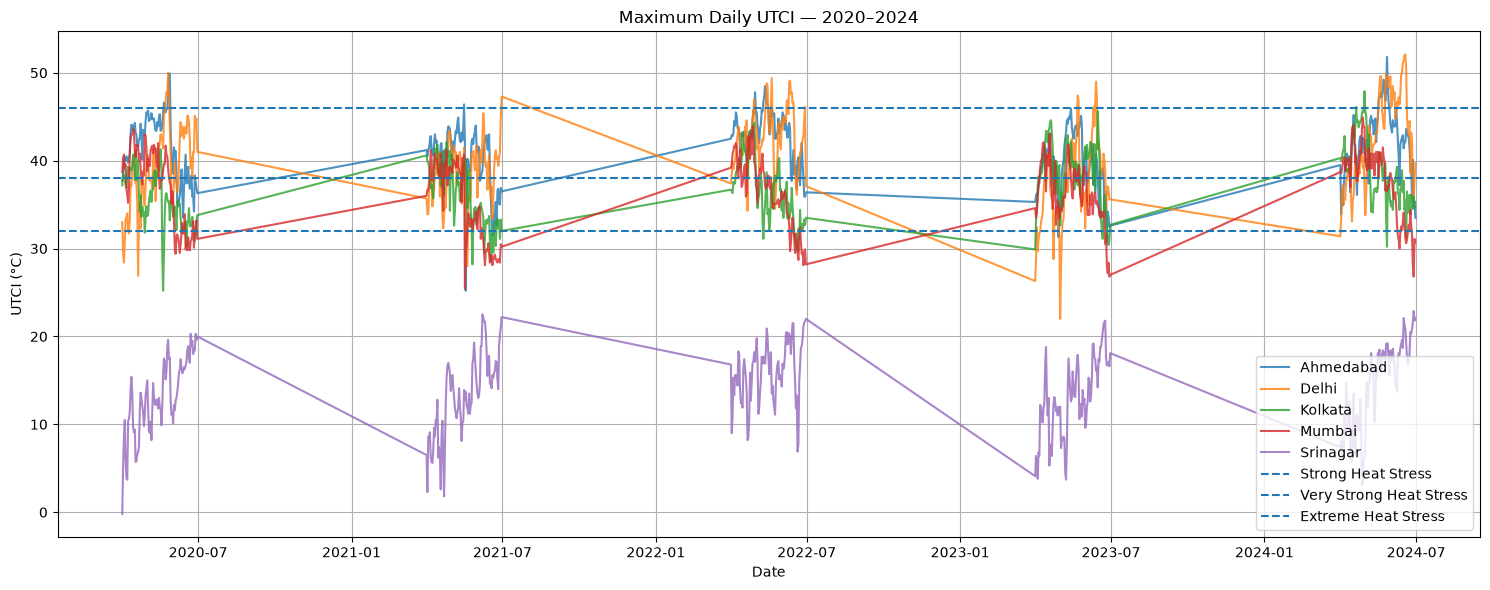

In [215]:
# ============================================================
# UTCI VISUALIZATION
# ============================================================

plt.figure(figsize=(15, 6))

for city in daily["city"].unique():

    city_data = daily[
        daily["city"] == city
    ]

    plt.plot(
        city_data["date"],
        city_data["max_utci_c"],
        label=city,
        alpha=0.8
    )

plt.axhline(
    32,
    linestyle="--",
    label="Strong Heat Stress"
)

plt.axhline(
    38,
    linestyle="--",
    label="Very Strong Heat Stress"
)

plt.axhline(
    46,
    linestyle="--",
    label="Extreme Heat Stress"
)

plt.title(
    "Maximum Daily UTCI — 2020–2024"
)

plt.xlabel("Date")
plt.ylabel("UTCI (°C)")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

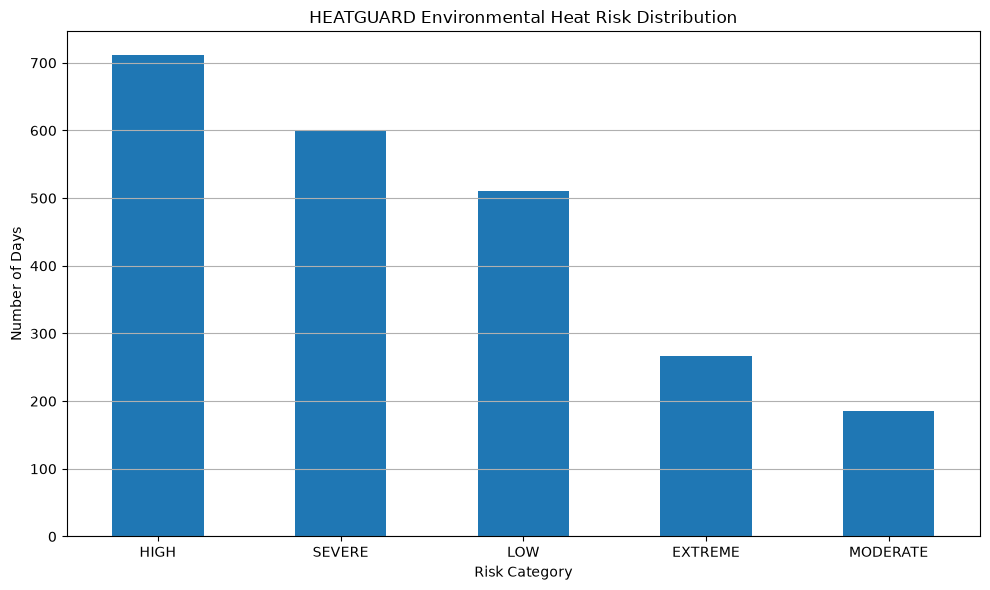

In [216]:
# ============================================================
# RISK DISTRIBUTION
# ============================================================

risk_counts = (
    daily["risk_category"]
    .value_counts()
)

plt.figure(figsize=(10, 6))

risk_counts.plot(
    kind="bar"
)

plt.title(
    "HEATGUARD Environmental Heat Risk Distribution"
)

plt.xlabel("Risk Category")
plt.ylabel("Number of Days")

plt.xticks(rotation=0)

plt.grid(
    axis="y"
)

plt.tight_layout()
plt.show()

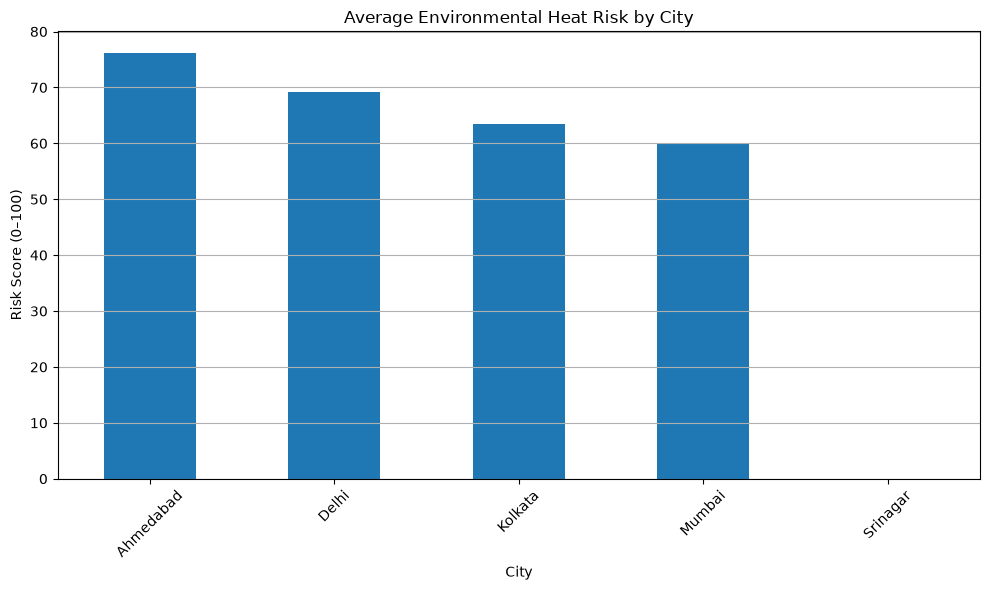

In [217]:
# ============================================================
# CITY RISK COMPARISON
# ============================================================

city_risk = (
    daily
    .groupby("city")[
        "environmental_heat_risk"
    ]
    .mean()
    .sort_values(
        ascending=False
    )
)

plt.figure(figsize=(10, 6))

city_risk.plot(
    kind="bar"
)

plt.title(
    "Average Environmental Heat Risk by City"
)

plt.xlabel("City")
plt.ylabel("Risk Score (0–100)")

plt.xticks(rotation=45)

plt.grid(
    axis="y"
)

plt.tight_layout()
plt.show()

In [218]:
# ============================================================
# SAVE DATASETS
# ============================================================

hourly_file = (
    "HEATGUARD_hourly_thermal_dataset.csv"
)

daily_file = (
    "HEATGUARD_daily_thermal_dataset.csv"
)

weather.to_csv(
    hourly_file,
    index=False
)

daily.to_csv(
    daily_file,
    index=False
)

print("Saved:")
print(hourly_file)
print(daily_file)

Saved:
HEATGUARD_hourly_thermal_dataset.csv
HEATGUARD_daily_thermal_dataset.csv


In [219]:
import os

file_path = "HEATGUARD_daily_thermal_dataset.csv"

if os.path.exists(file_path):
    print(f"File ready: {os.path.abspath(file_path)}")
else:
    print("File not found:", file_path)

File ready: c:\Users\Puspal\OneDrive\Desktop\HeatGuard\HEATGUARD_daily_thermal_dataset.csv


In [220]:
import warnings
warnings.filterwarnings("ignore")

In [221]:
# ============================================================
# HEATGUARD - MACHINE LEARNING SETUP
# ============================================================

!pip -q install xgboost scikit-learn shap

In [222]:
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import shap

print("ML libraries loaded successfully!")

ML libraries loaded successfully!


In [223]:
# ============================================================
# PREPARE ML DATASET
# ============================================================

ml_data = daily.copy()

ml_data = ml_data.sort_values(
    ["city", "date"]
).reset_index(drop=True)

print("ML dataset shape:", ml_data.shape)

ml_data.head()


ML dataset shape: (2275, 35)


,city,latitude,longitude,date,mean_temperature_c,max_temperature_c,min_temperature_c,mean_humidity,max_humidity,mean_wind_speed,...,utci_5day_mean,temperature_3day_mean,night_temp_3day_mean,hot_day,hot_night,consecutive_hot_days,consecutive_hot_nights,persistence_score,environmental_heat_risk,risk_category
0,Ahmedabad,23.0225,72.5714,2020-04-01,29.646667,38.73,20.98,31.005833,65.10,3.780000,...,26.837500,29.646667,20.980000,1,0,1,0,12.0,39.08,MODERATE
1,Ahmedabad,23.0225,72.5714,2020-04-02,30.282500,39.27,20.84,21.712917,37.76,2.296250,...,27.316667,29.964583,20.910000,1,0,2,0,24.0,43.74,MODERATE
2,Ahmedabad,23.0225,72.5714,2020-04-03,30.866250,40.72,21.47,19.607083,33.95,3.050417,...,27.405556,30.265139,21.096667,1,0,3,0,36.0,51.57,HIGH
3,Ahmedabad,23.0225,72.5714,2020-04-04,31.323333,41.15,20.94,18.462500,33.98,2.962500,...,27.691667,30.824028,21.083333,1,0,4,0,48.0,56.14,HIGH
4,Ahmedabad,23.0225,72.5714,2020-04-05,31.977500,41.16,22.07,17.380833,27.78,2.454167,...,27.990000,31.389028,21.493333,1,0,5,0,60.0,59.37,HIGH


In [224]:
# ============================================================
# TARGET VARIABLE
# ============================================================

ml_data["heat_event"] = (
    ml_data["max_utci_c"] >= 32
).astype(int)

print(
    ml_data["heat_event"].value_counts()
)

print(
    "\nHeat-event percentage:",
    round(
        ml_data["heat_event"].mean() * 100,
        2
    ),
    "%"
)

heat_event
1    1675
0     600
Name: count, dtype: int64

Heat-event percentage: 73.63 %


In [225]:
# ============================================================
# FUTURE HEAT EVENT TARGETS
# ============================================================

for days_ahead in range(1, 6):

    ml_data[
        f"heat_event_{days_ahead}d"
    ] = (
        ml_data
        .groupby("city")["heat_event"]
        .shift(-days_ahead)
    )

ml_data[
    [
        "city",
        "date",
        "heat_event",
        "heat_event_1d",
        "heat_event_2d",
        "heat_event_3d",
        "heat_event_4d",
        "heat_event_5d"
    ]
].head(15)

,city,date,heat_event,heat_event_1d,heat_event_2d,heat_event_3d,heat_event_4d,heat_event_5d
0,Ahmedabad,2020-04-01,1,1.0,1.0,1.0,1.0,1.0
1,Ahmedabad,2020-04-02,1,1.0,1.0,1.0,1.0,1.0
2,Ahmedabad,2020-04-03,1,1.0,1.0,1.0,1.0,1.0
3,Ahmedabad,2020-04-04,1,1.0,1.0,1.0,1.0,1.0
4,Ahmedabad,2020-04-05,1,1.0,1.0,1.0,1.0,1.0
5,Ahmedabad,2020-04-06,1,1.0,1.0,1.0,1.0,1.0
6,Ahmedabad,2020-04-07,1,1.0,1.0,1.0,1.0,1.0
7,Ahmedabad,2020-04-08,1,1.0,1.0,1.0,1.0,1.0
8,Ahmedabad,2020-04-09,1,1.0,1.0,1.0,1.0,1.0
9,Ahmedabad,2020-04-10,1,1.0,1.0,1.0,1.0,1.0


In [226]:
# ============================================================
# LAG FEATURES
# ============================================================

lag_features = [
    "max_temperature_c",
    "mean_temperature_c",
    "min_temperature_c",
    "mean_humidity",
    "max_humidity",
    "mean_wind_speed",
    "mean_utci_c",
    "max_utci_c",
    "max_wbgt_c",
    "max_heat_index_c",
    "nighttime_min_temperature_c",
    "mean_thermal_stress",
    "max_thermal_stress"
]

for feature in lag_features:

    for lag in [1, 2, 3, 5]:

        ml_data[
            f"{feature}_lag{lag}"
        ] = (
            ml_data
            .groupby("city")[feature]
            .shift(lag)
        )

print(
    "Lag features created."
)

Lag features created.


In [227]:
# ============================================================
# ROLLING FEATURES
# ============================================================

for feature in [
    "max_utci_c",
    "mean_utci_c",
    "max_temperature_c",
    "nighttime_min_temperature_c",
    "mean_thermal_stress"
]:

    ml_data[
        f"{feature}_rolling3"
    ] = (
        ml_data
        .groupby("city")[feature]
        .transform(
            lambda x:
            x.rolling(
                3,
                min_periods=3
            ).mean()
        )
    )

    ml_data[
        f"{feature}_rolling5"
    ] = (
        ml_data
        .groupby("city")[feature]
        .transform(
            lambda x:
            x.rolling(
                5,
                min_periods=5
            ).mean()
        )
    )

print("Rolling features created.")

Rolling features created.


In [228]:
# ============================================================
# SEASONAL FEATURES
# ============================================================

ml_data["day_of_year"] = (
    ml_data["date"].dt.dayofyear
)

ml_data["month"] = (
    ml_data["date"].dt.month
)

# Cyclic encoding
ml_data["sin_day"] = np.sin(
    2 * np.pi *
    ml_data["day_of_year"] / 365
)

ml_data["cos_day"] = np.cos(
    2 * np.pi *
    ml_data["day_of_year"] / 365
)

print(
    ml_data[
        [
            "date",
            "day_of_year",
            "sin_day",
            "cos_day"
        ]
    ].head()
)

        date  day_of_year   sin_day   cos_day
0 2020-04-01           92  0.999917 -0.012910
1 2020-04-02           93  0.999546 -0.030120
2 2020-04-03           94  0.998880 -0.047321
3 2020-04-04           95  0.997917 -0.064508
4 2020-04-05           96  0.996659 -0.081676


In [229]:
# ============================================================
# CITY ENCODING
# ============================================================

ml_data_encoded = pd.get_dummies(
    ml_data,
    columns=["city"],
    prefix="city",
    dtype=int
)

print(
    ml_data_encoded.shape
)

(2275, 111)


In [230]:
# ============================================================
# MODEL FEATURES
# ============================================================

exclude_columns = [
    "date",
    "heat_event",
    "heat_event_1d",
    "heat_event_2d",
    "heat_event_3d",
    "heat_event_4d",
    "heat_event_5d",
    "risk_category"
]

feature_columns = [
    col
    for col in ml_data_encoded.columns
    if col not in exclude_columns
]

print(
    "Number of features:",
    len(feature_columns)
)

print(
    "\nFeatures:"
)

for feature in feature_columns:
    print(feature)

Number of features: 103

Features:
latitude
longitude
mean_temperature_c
max_temperature_c
min_temperature_c
mean_humidity
max_humidity
mean_wind_speed
max_solar_radiation
mean_utci_c
max_utci_c
min_utci_c
mean_wbgt_c
max_wbgt_c
max_heat_index_c
max_thermal_stress
mean_thermal_stress
precipitation_mm
nighttime_min_temperature_c
nighttime_mean_utci_c
nighttime_max_utci_c
utci_3day_mean
utci_3day_max
utci_5day_mean
temperature_3day_mean
night_temp_3day_mean
hot_day
hot_night
consecutive_hot_days
consecutive_hot_nights
persistence_score
environmental_heat_risk
max_temperature_c_lag1
max_temperature_c_lag2
max_temperature_c_lag3
max_temperature_c_lag5
mean_temperature_c_lag1
mean_temperature_c_lag2
mean_temperature_c_lag3
mean_temperature_c_lag5
min_temperature_c_lag1
min_temperature_c_lag2
min_temperature_c_lag3
min_temperature_c_lag5
mean_humidity_lag1
mean_humidity_lag2
mean_humidity_lag3
mean_humidity_lag5
max_humidity_lag1
max_humidity_lag2
max_humidity_lag3
max_humidity_lag5
mean_win

In [231]:
# ============================================================
# TIME-BASED TRAIN/TEST SPLIT
# ============================================================

train_data = ml_data_encoded[
    ml_data_encoded["date"] <
    "2024-01-01"
].copy()

test_data = ml_data_encoded[
    ml_data_encoded["date"] >=
    "2024-01-01"
].copy()

print(
    "Training:",
    train_data.shape
)

print(
    "Testing:",
    test_data.shape
)

Training: (1820, 111)
Testing: (455, 111)


In [232]:
# ============================================================
# REMOVE INCOMPLETE ROWS
# ============================================================

train_data = train_data.dropna(
    subset=feature_columns
)

test_data = test_data.dropna(
    subset=feature_columns
)

print(
    "Training rows:",
    len(train_data)
)

print(
    "Testing rows:",
    len(test_data)
)

Training rows: 1795
Testing rows: 455


In [233]:
# ============================================================
# 1-DAY HEAT EVENT MODEL
# ============================================================

X_train = train_data[
    feature_columns
]

y_train = train_data[
    "heat_event_1d"
]

X_test = test_data[
    feature_columns
]

y_test = test_data[
    "heat_event_1d"
]

# Remove any remaining missing target rows
valid_train = y_train.notna()
valid_test = y_test.notna()

X_train = X_train[
    valid_train
]

y_train = y_train[
    valid_train
]

X_test = X_test[
    valid_test
]

y_test = y_test[
    valid_test
]

model_1d = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

model_1d.fit(
    X_train,
    y_train
)

print("1-day model trained successfully!")

1-day model trained successfully!


In [234]:
# ============================================================
# MODEL EVALUATION
# ============================================================

y_pred = model_1d.predict(
    X_test
)

y_probability = model_1d.predict_proba(
    X_test
)[:, 1]

print(
    "Accuracy:",
    round(
        accuracy_score(
            y_test,
            y_pred
        ),
        4
    )
)

print(
    "\nROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            y_probability
        ),
        4
    )
)

print(
    "\nClassification Report:"
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 0.9822

ROC-AUC: 0.9977

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.94      0.96       105
         1.0       0.98      0.99      0.99       345

    accuracy                           0.98       450
   macro avg       0.98      0.97      0.97       450
weighted avg       0.98      0.98      0.98       450



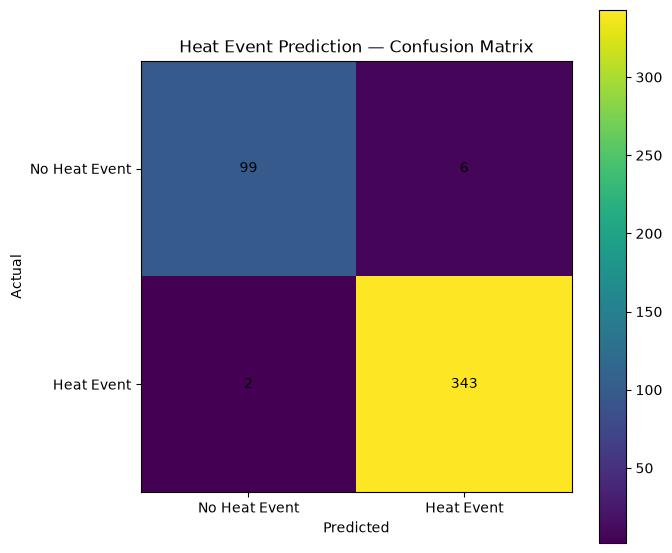

In [235]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7, 6))

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.colorbar()

plt.title(
    "Heat Event Prediction — Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.xticks(
    [0, 1],
    ["No Heat Event", "Heat Event"]
)

plt.yticks(
    [0, 1],
    ["No Heat Event", "Heat Event"]
)

for i in range(2):

    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

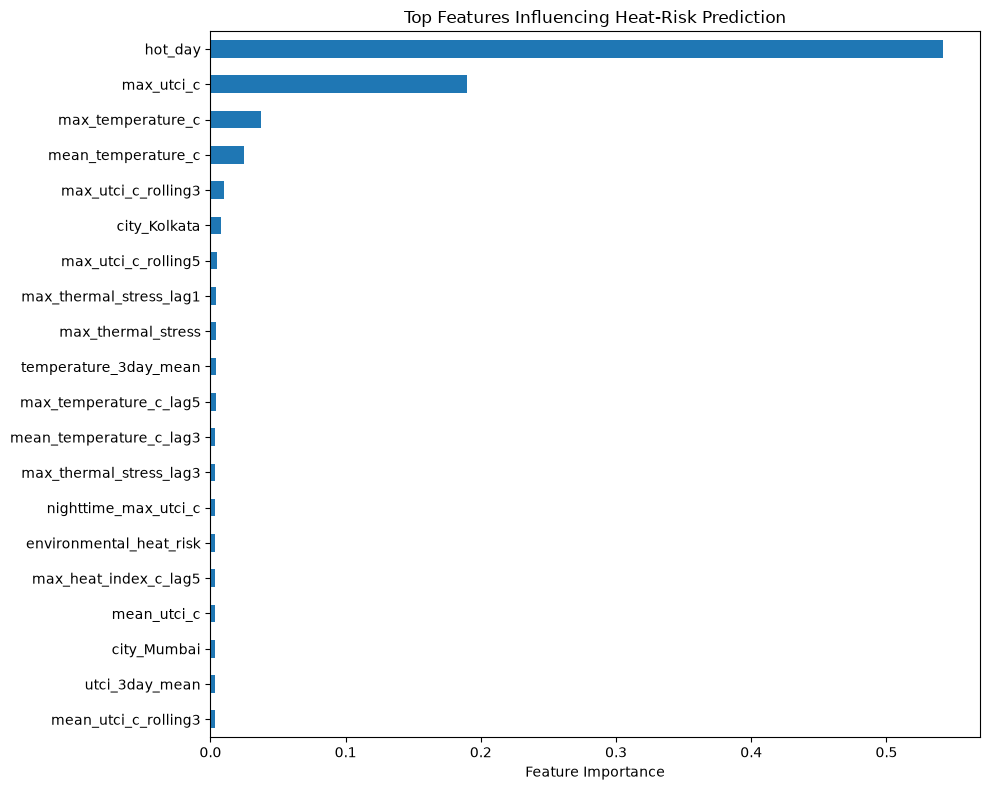

In [236]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

importance = pd.Series(
    model_1d.feature_importances_,
    index=feature_columns
).sort_values(
    ascending=False
)

top_features = importance.head(20)

plt.figure(figsize=(10, 8))

top_features.sort_values().plot(
    kind="barh"
)

plt.title(
    "Top Features Influencing Heat-Risk Prediction"
)

plt.xlabel(
    "Feature Importance"
)

plt.tight_layout()
plt.show()

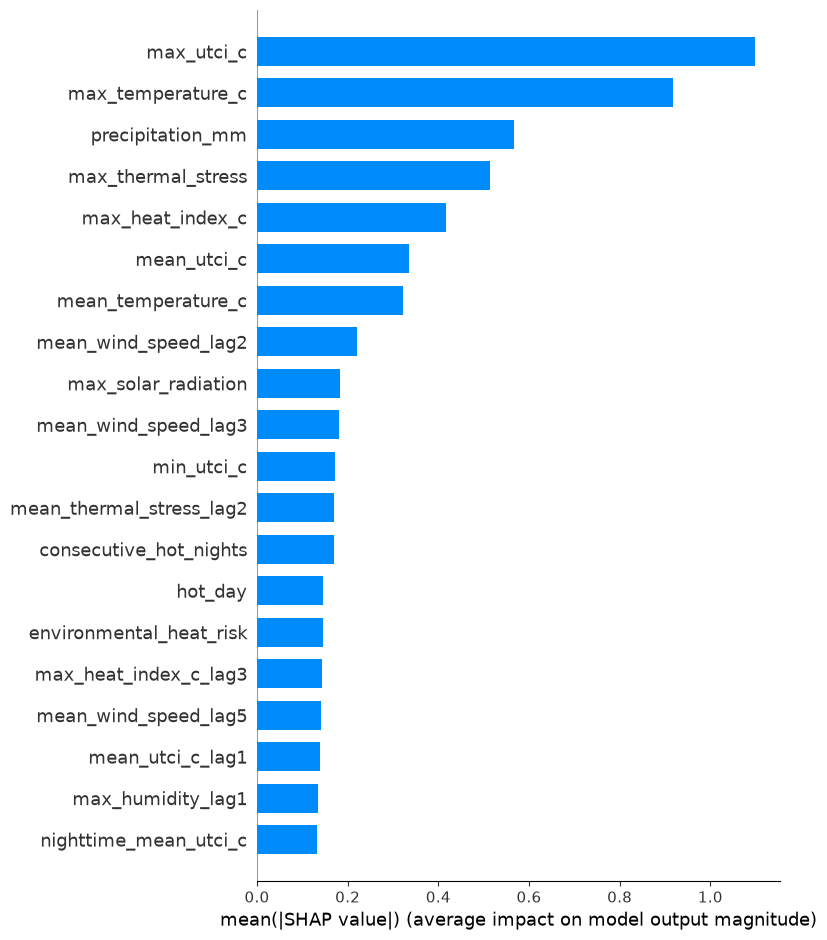

In [237]:
# ============================================================
# SHAP EXPLAINABILITY
# ============================================================

explainer = shap.TreeExplainer(
    model_1d
)

sample_X = X_test.sample(
    min(1000, len(X_test)),
    random_state=42
)

shap_values = explainer(
    sample_X
)

shap.summary_plot(
    shap_values,
    sample_X,
    plot_type="bar"
)

In [238]:
# ============================================================
# 3–5 DAY EARLY WARNING MODELS
# ============================================================

models = {}
predictions = {}

for days_ahead in range(1, 6):

    target = f"heat_event_{days_ahead}d"

    train_subset = train_data.dropna(
        subset=[target] + feature_columns
    )

    test_subset = test_data.dropna(
        subset=[target] + feature_columns
    )

    X_tr = train_subset[
        feature_columns
    ]

    y_tr = train_subset[
        target
    ]

    X_te = test_subset[
        feature_columns
    ]

    y_te = test_subset[
        target
    ]

    model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    )

    model.fit(
        X_tr,
        y_tr
    )

    probability = model.predict_proba(
        X_te
    )[:, 1]

    prediction = (
        probability >= 0.5
    ).astype(int)

    auc = roc_auc_score(
        y_te,
        probability
    )

    models[days_ahead] = model

    predictions[days_ahead] = {
        "probability": probability,
        "prediction": prediction,
        "actual": y_te.values,
        "auc": auc
    }

    print(
        f"{days_ahead}-day model ROC-AUC: "
        f"{auc:.3f}"
    )

1-day model ROC-AUC: 0.998
2-day model ROC-AUC: 0.993
3-day model ROC-AUC: 0.991
4-day model ROC-AUC: 0.990
5-day model ROC-AUC: 0.988


In [239]:
# ============================================================
# 5-DAY EARLY WARNING TABLE
# ============================================================

# Ensure forecast_table has the same index as the original test_data
forecast_table = test_data[["date"]].copy()

for days_ahead in range(1, 6):
    target = f"heat_event_{days_ahead}d"

    # Re-create the test_subset for this specific target and features
    # to get the correct index alignment for the predictions
    current_test_subset_indices = test_data.dropna(
        subset=[target] + feature_columns
    ).index

    # Create a Series for the probabilities, using the indices from current_test_subset
    prob_series = pd.Series(
        predictions[days_ahead]["probability"],
        index=current_test_subset_indices
    )

    # Assign the probability series to the forecast_table.
    # Pandas will align by index; rows in forecast_table but not in prob_series will get NaN.
    forecast_table[
        f"risk_probability_{days_ahead}d"
    ] = prob_series

forecast_table.head()

,date,risk_probability_1d,risk_probability_2d,risk_probability_3d,risk_probability_4d,risk_probability_5d
364,2024-04-01,0.999553,0.999660,0.998561,0.996052,0.994170
365,2024-04-02,0.999137,0.981322,0.996543,0.983067,0.997740
366,2024-04-03,0.996061,0.998458,0.996676,0.999242,0.999289
367,2024-04-04,0.995907,0.979438,0.990128,0.997733,0.996316
368,2024-04-05,0.997698,0.997827,0.998004,0.998819,0.999006


In [240]:
# ============================================================
# WARNING LEVEL
# ============================================================

def probability_to_warning(probability):

    if probability < 0.25:
        return "LOW"

    elif probability < 0.50:
        return "MODERATE"

    elif probability < 0.70:
        return "HIGH"

    elif probability < 0.85:
        return "SEVERE"

    else:
        return "EXTREME"


for days_ahead in range(1, 6):

    forecast_table[
        f"warning_{days_ahead}d"
    ] = (
        forecast_table[
            f"risk_probability_{days_ahead}d"
        ]
        .apply(probability_to_warning)
    )

forecast_table.head()

,date,risk_probability_1d,risk_probability_2d,risk_probability_3d,risk_probability_4d,risk_probability_5d,warning_1d,warning_2d,warning_3d,warning_4d,warning_5d
364,2024-04-01,0.999553,0.999660,0.998561,0.996052,0.994170,EXTREME,EXTREME,EXTREME,EXTREME,EXTREME
365,2024-04-02,0.999137,0.981322,0.996543,0.983067,0.997740,EXTREME,EXTREME,EXTREME,EXTREME,EXTREME
366,2024-04-03,0.996061,0.998458,0.996676,0.999242,0.999289,EXTREME,EXTREME,EXTREME,EXTREME,EXTREME
367,2024-04-04,0.995907,0.979438,0.990128,0.997733,0.996316,EXTREME,EXTREME,EXTREME,EXTREME,EXTREME
368,2024-04-05,0.997698,0.997827,0.998004,0.998819,0.999006,EXTREME,EXTREME,EXTREME,EXTREME,EXTREME


In [241]:
# ============================================================
# KOLKATA FORECAST
# ============================================================

kolkata_forecast = test_data[
    test_data["city_Kolkata"] == 1
].copy()

print(
    "Kolkata forecast observations:",
    len(kolkata_forecast)
)

Kolkata forecast observations: 91


In [242]:
# ============================================================
# LATEST KOLKATA PREDICTION
# ============================================================

latest_kolkata = (
    ml_data_encoded[
        (ml_data_encoded["city_Kolkata"] == 1)
    ]
    .sort_values("date")
    .iloc[-1]
)

latest_date = latest_kolkata["date"]

print(
    "Latest available Kolkata date:",
    latest_date
)

Latest available Kolkata date: 2024-06-30 00:00:00


In [243]:
latest_X = latest_kolkata[
    feature_columns
].to_frame().T

print(
    latest_X.shape
)

(1, 103)


In [244]:
# ============================================================
# NEXT 5 DAYS
# ============================================================

future_predictions = []

# Ensure all feature columns in latest_X are numeric before prediction.
# When a pandas Series (latest_kolkata) containing mixed data types (e.g., numbers and datetime objects)
# is selected for specific columns and then transposed into a DataFrame (latest_X),
# the numeric columns might retain an 'object' dtype if not explicitly converted.
# This conversion ensures XGBoost receives appropriate data types.
latest_X = latest_X[feature_columns].apply(pd.to_numeric, errors='coerce')

for days_ahead in range(1, 6):

    model = models[days_ahead]

    probability = model.predict_proba(
        latest_X
    )[0, 1]

    warning = probability_to_warning(
        probability
    )

    future_predictions.append({
        "forecast_horizon": f"+{days_ahead} day",
        "risk_probability": probability,
        "warning_level": warning
    })

future_forecast = pd.DataFrame(
    future_predictions
)

future_forecast

,forecast_horizon,risk_probability,warning_level
0,+1 day,0.798654,SEVERE
1,+2 day,0.574114,HIGH
2,+3 day,0.900477,EXTREME
3,+4 day,0.987633,EXTREME
4,+5 day,0.985567,EXTREME


In [245]:
# ============================================================
# AUTOMATED ADVISORY
# ============================================================

def generate_advisory(
    city,
    forecast_df
):

    max_row = forecast_df.loc[
        forecast_df[
            "risk_probability"
        ].idxmax()
    ]

    probability = (
        max_row["risk_probability"]
    )

    level = (
        max_row["warning_level"]
    )

    horizon = (
        max_row["forecast_horizon"]
    )

    if level == "EXTREME":

        advice = (
            "Extreme heat stress expected. "
            "Avoid non-essential outdoor activity, "
            "activate cooling resources, ensure hydration, "
            "and prioritize vulnerable populations."
        )

    elif level == "SEVERE":

        advice = (
            "Severe heat stress expected. "
            "Reduce prolonged outdoor exposure, "
            "increase hydration, and consider adjusting "
            "outdoor work schedules."
        )

    elif level == "HIGH":

        advice = (
            "High heat stress expected. "
            "Increase hydration and limit prolonged "
            "outdoor exposure during peak heat."
        )

    elif level == "MODERATE":

        advice = (
            "Moderate heat stress possible. "
            "Stay hydrated and monitor heat exposure."
        )

    else:

        advice = (
            "No significant heat stress warning."
        )

    return {
        "city": city,
        "peak_horizon": horizon,
        "risk_probability": round(
            probability * 100,
            1
        ),
        "warning_level": level,
        "advisory": advice
    }


advisory = generate_advisory(
    "Kolkata",
    future_forecast
)

advisory

{'city': 'Kolkata',
 'peak_horizon': '+4 day',
 'risk_probability': np.float32(98.8),
 'warning_level': 'EXTREME',
 'advisory': 'Extreme heat stress expected. Avoid non-essential outdoor activity, activate cooling resources, ensure hydration, and prioritize vulnerable populations.'}

In [246]:
# ============================================================
# SAVE PREDICTION RESULTS
# ============================================================

future_forecast.to_csv(
    "HEATGUARD_5_day_heat_warning.csv",
    index=False
)

print(
    "Saved HEATGUARD_5_day_heat_warning.csv"
)

Saved HEATGUARD_5_day_heat_warning.csv


In [247]:
# ============================================================
# STEP 8 — HEATGUARD MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import pandas as pd
import numpy as np

evaluation_results = []

for days_ahead in range(1, 6):

    target = f"heat_event_{days_ahead}d"

    # Remove rows with missing target/features
    train_subset = train_data.dropna(
        subset=[target] + feature_columns
    )

    test_subset = test_data.dropna(
        subset=[target] + feature_columns
    )

    X_train = train_subset[feature_columns]
    y_train = train_subset[target].astype(int)

    X_test = test_subset[feature_columns]
    y_test = test_subset[target].astype(int)

    # --------------------------------------------------------
    # Train model
    # --------------------------------------------------------

    model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    )

    model.fit(X_train, y_train)

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    y_probability = model.predict_proba(X_test)[:, 1]

    y_prediction = (
        y_probability >= 0.5
    ).astype(int)

    # --------------------------------------------------------
    # Evaluation metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_prediction
    )

    precision = precision_score(
        y_test,
        y_prediction,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_prediction,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_prediction,
        zero_division=0
    )

    if len(np.unique(y_test)) == 2:
        auc = roc_auc_score(
            y_test,
            y_probability
        )
    else:
        auc = np.nan

    evaluation_results.append({
        "Forecast Horizon": f"+{days_ahead} Day",
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": auc
    })


# ============================================================
# DISPLAY RESULTS
# ============================================================

evaluation_df = pd.DataFrame(
    evaluation_results
)

evaluation_display = evaluation_df.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

for column in metric_columns:

    evaluation_display[column] = (
        evaluation_display[column] * 100
    ).round(2)

evaluation_display

,Forecast Horizon,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,+1 Day,98.22,98.28,99.42,98.85,99.77
1,+2 Day,95.73,97.35,97.07,97.21,99.30
2,+3 Day,96.36,97.91,97.33,97.62,99.10
3,+4 Day,95.63,97.58,96.70,97.13,99.03
4,+5 Day,96.05,97.56,97.26,97.41,98.82


In [248]:
# ============================================================
# CLASS DISTRIBUTION
# ============================================================

print("HEAT EVENT DISTRIBUTION")
print("=" * 50)

for days_ahead in range(1, 6):

    target = f"heat_event_{days_ahead}d"

    counts = (
        ml_data[target]
        .value_counts(dropna=True)
        .sort_index()
    )

    total = counts.sum()

    print(f"\n+{days_ahead} Day:")

    for class_value, count in counts.items():

        label = (
            "No Heat Event"
            if class_value == 0
            else "Heat Event"
        )

        percentage = (
            count / total * 100
        )

        print(
            f"  {label}: "
            f"{count:.0f} "
            f"({percentage:.2f}%)"
        )

HEAT EVENT DISTRIBUTION

+1 Day:
  No Heat Event: 599 (26.39%)
  Heat Event: 1671 (73.61%)

+2 Day:
  No Heat Event: 597 (26.36%)
  Heat Event: 1668 (73.64%)

+3 Day:
  No Heat Event: 595 (26.33%)
  Heat Event: 1665 (73.67%)

+4 Day:
  No Heat Event: 593 (26.30%)
  Heat Event: 1662 (73.70%)

+5 Day:
  No Heat Event: 592 (26.31%)
  Heat Event: 1658 (73.69%)


In [249]:
# ============================================================
# CONFUSION MATRIX — 1 DAY AHEAD
# ============================================================

days_ahead = 1

target = f"heat_event_{days_ahead}d"

train_subset = train_data.dropna(
    subset=[target] + feature_columns
)

test_subset = test_data.dropna(
    subset=[target] + feature_columns
)

X_train = train_subset[feature_columns]
y_train = train_subset[target].astype(int)

X_test = test_subset[feature_columns]
y_test = test_subset[target].astype(int)

model_1day = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

model_1day.fit(
    X_train,
    y_train
)

y_pred = model_1day.predict(
    X_test
)

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix")
print(cm)

print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Heat Event",
            "Heat Event"
        ],
        zero_division=0
    )
)

Confusion Matrix
[[ 99   6]
 [  2 343]]

Classification Report
               precision    recall  f1-score   support

No Heat Event       0.98      0.94      0.96       105
   Heat Event       0.98      0.99      0.99       345

     accuracy                           0.98       450
    macro avg       0.98      0.97      0.97       450
 weighted avg       0.98      0.98      0.98       450



In [250]:
# ============================================================
# 5-DAY HEAT WARNING PREDICTION
# ============================================================

latest_kolkata = ml_data_encoded[ml_data_encoded["city_Kolkata"] == 1].sort_values("date").iloc[-1]

latest_X = latest_kolkata[feature_columns].to_frame().T
latest_X = latest_X[feature_columns].apply(pd.to_numeric, errors="coerce")

prediction_results = []

for days_ahead in range(1, 6):

    model = models[days_ahead]

    probability = model.predict_proba(latest_X)[0, 1] * 100

    prediction = "HEAT EVENT" if probability >= 50 else "NO HEAT EVENT"

    if probability < 25:
        warning = "LOW"
    elif probability < 50:
        warning = "MODERATE"
    elif probability < 70:
        warning = "HIGH"
    elif probability < 85:
        warning = "SEVERE"
    else:
        warning = "EXTREME"

    prediction_results.append({
        "City": "Kolkata",
        "Forecast Day": f"+{days_ahead} day",
        "Risk Probability (%)": round(probability, 2),
        "Prediction": prediction,
        "Warning Level": warning
    })

prediction_results = pd.DataFrame(prediction_results)

prediction_results

,City,Forecast Day,Risk Probability (%),Prediction,Warning Level
0,Kolkata,+1 day,79.870003,HEAT EVENT,SEVERE
1,Kolkata,+2 day,57.410000,HEAT EVENT,HIGH
2,Kolkata,+3 day,90.050003,HEAT EVENT,EXTREME
3,Kolkata,+4 day,98.760002,HEAT EVENT,EXTREME
4,Kolkata,+5 day,98.559998,HEAT EVENT,EXTREME


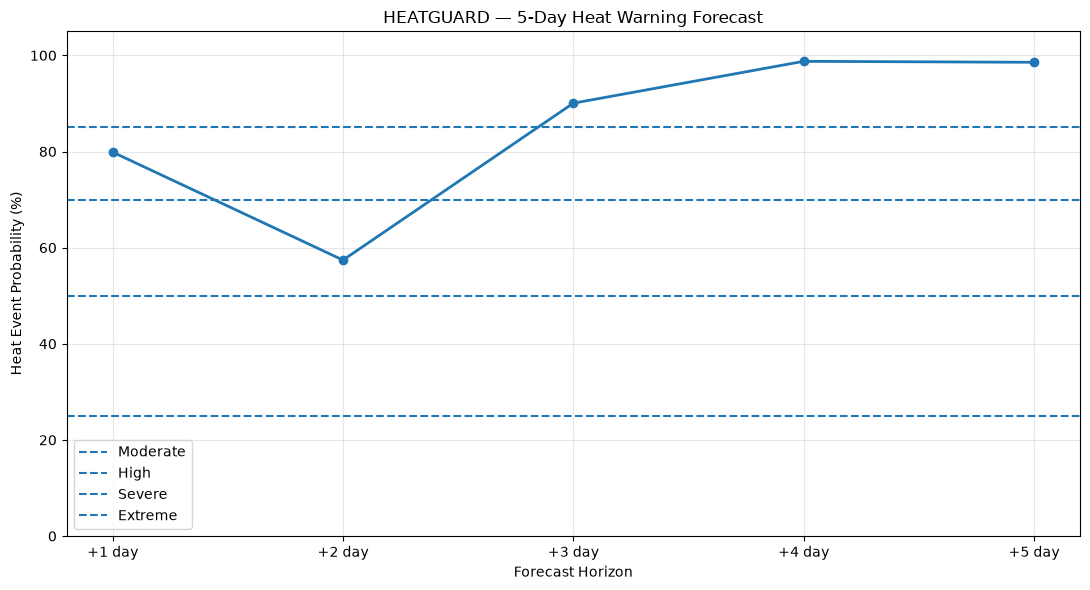

In [251]:
# ============================================================
# STEP 10.1 — 5-DAY HEAT RISK TRAJECTORY
# ============================================================

import matplotlib.pyplot as plt

plot_data = prediction_results.copy()

plt.figure(figsize=(11, 6))

plt.plot(
    plot_data["Forecast Day"],
    plot_data["Risk Probability (%)"],
    marker="o",
    linewidth=2
)

# Warning thresholds
plt.axhline(
    25,
    linestyle="--",
    label="Moderate"
)

plt.axhline(
    50,
    linestyle="--",
    label="High"
)

plt.axhline(
    70,
    linestyle="--",
    label="Severe"
)

plt.axhline(
    85,
    linestyle="--",
    label="Extreme"
)

plt.xlabel("Forecast Horizon")
plt.ylabel("Heat Event Probability (%)")

plt.title(
    "HEATGUARD — 5-Day Heat Warning Forecast"
)

plt.ylim(0, 105)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.show()

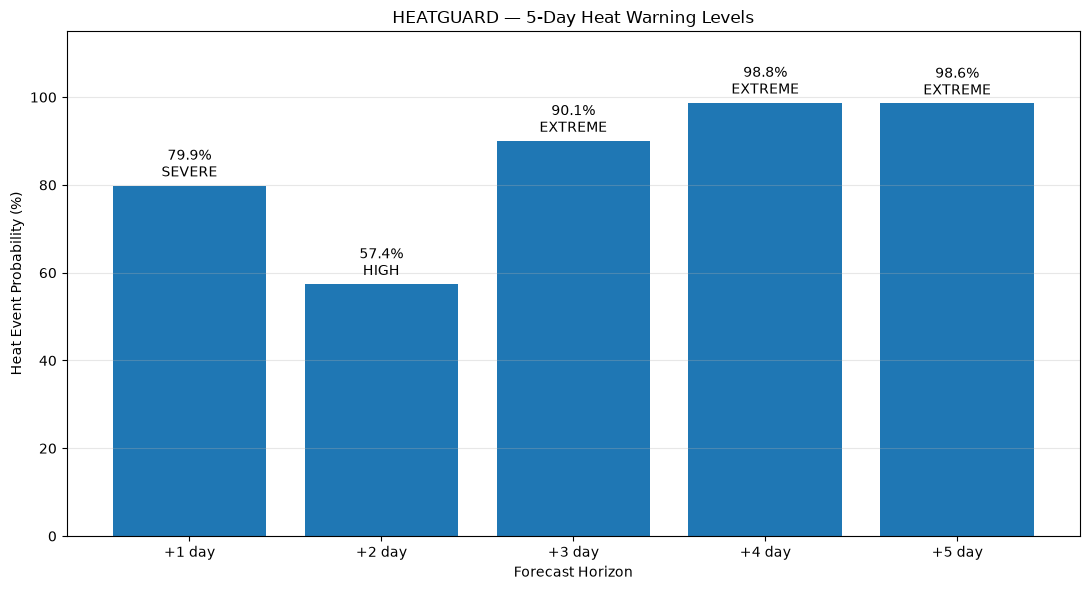

In [252]:
# ============================================================
# STEP 10.2 — 5-DAY WARNING LEVEL VISUALIZATION
# ============================================================

plt.figure(figsize=(11, 6))

bars = plt.bar(
    plot_data["Forecast Day"],
    plot_data["Risk Probability (%)"]
)

for bar, probability, warning in zip(
    bars,
    plot_data["Risk Probability (%)"],
    plot_data["Warning Level"]
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{probability:.1f}%\n{warning}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.xlabel("Forecast Horizon")
plt.ylabel("Heat Event Probability (%)")

plt.title(
    "HEATGUARD — 5-Day Heat Warning Levels"
)

plt.ylim(0, 115)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

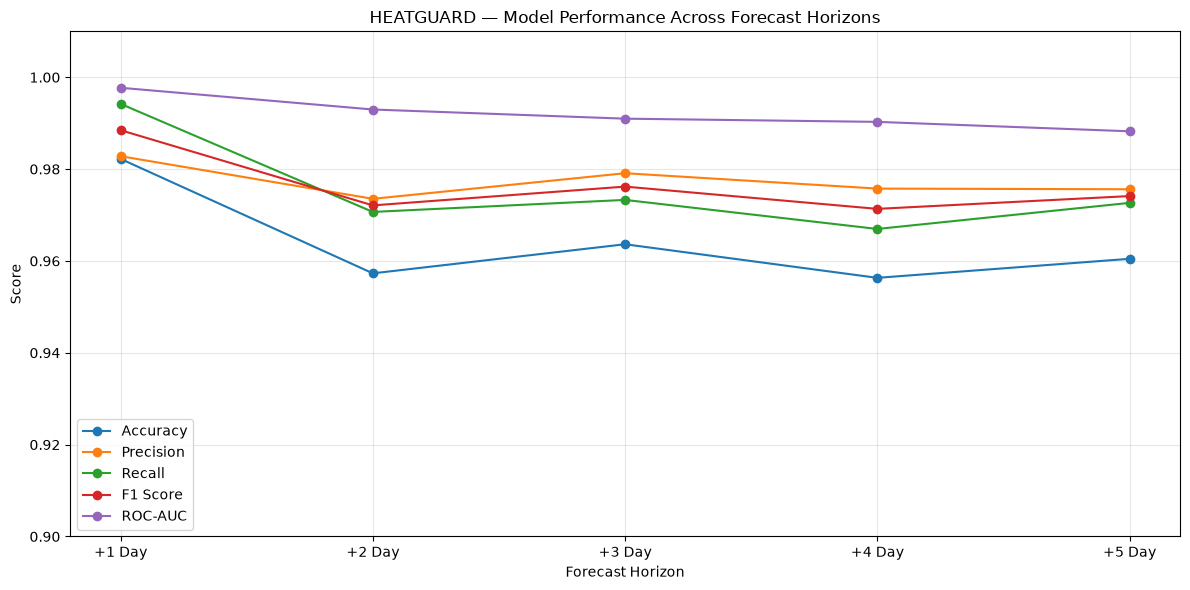

In [253]:
# ============================================================
# STEP 10.3 — MODEL PERFORMANCE BY FORECAST HORIZON
# ============================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

plt.figure(figsize=(12, 6))

for metric in metrics:

    plt.plot(
        evaluation_df["Forecast Horizon"],
        evaluation_df[metric],
        marker="o",
        label=metric
    )

plt.xlabel("Forecast Horizon")
plt.ylabel("Score")

plt.title(
    "HEATGUARD — Model Performance Across Forecast Horizons"
)

plt.ylim(0.90, 1.01)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.show()

In [254]:
# ============================================================
# PHASE 5 — HUMAN VULNERABILITY
# ============================================================

vulnerability = pd.DataFrame({

    "city": [
        "Kolkata",
        "Delhi",
        "Mumbai",
        "Ahmedabad",
        "Srinagar"
    ],

    # Relative vulnerability indicators
    # Prototype values: 0–100

    "elderly_vulnerability": [
        65, 60, 55, 50, 45
    ],

    "child_vulnerability": [
        60, 55, 55, 50, 45
    ],

    "outdoor_worker_vulnerability": [
        75, 80, 75, 85, 55
    ],

    "urban_exposure": [
        80, 90, 85, 75, 40
    ]
})

vulnerability

,city,elderly_vulnerability,child_vulnerability,outdoor_worker_vulnerability,urban_exposure
0,Kolkata,65,60,75,80
1,Delhi,60,55,80,90
2,Mumbai,55,55,75,85
3,Ahmedabad,50,50,85,75
4,Srinagar,45,45,55,40


In [255]:
# ============================================================
# VULNERABILITY SCORE
# ============================================================

vulnerability["vulnerability_score"] = (
    0.25 * vulnerability["elderly_vulnerability"] +
    0.20 * vulnerability["child_vulnerability"] +
    0.30 * vulnerability["outdoor_worker_vulnerability"] +
    0.25 * vulnerability["urban_exposure"]
)

vulnerability["vulnerability_score"] = (
    vulnerability["vulnerability_score"].round(2)
)

vulnerability[
    [
        "city",
        "vulnerability_score"
    ]
]

,city,vulnerability_score
0,Kolkata,70.75
1,Delhi,72.50
2,Mumbai,68.50
3,Ahmedabad,66.75
4,Srinagar,46.75


In [256]:
# ============================================================
# PHASE 6 — HUMAN HEAT HEALTH RISK
# ============================================================

health_forecast = prediction_results.merge(
    vulnerability[
        ["city", "vulnerability_score"]
    ],
    left_on="City",
    right_on="city",
    how="left"
)

health_forecast.drop(
    columns=["city"],
    inplace=True
)

health_forecast

,City,Forecast Day,Risk Probability (%),Prediction,Warning Level,vulnerability_score
0,Kolkata,+1 day,79.870003,HEAT EVENT,SEVERE,70.75
1,Kolkata,+2 day,57.410000,HEAT EVENT,HIGH,70.75
2,Kolkata,+3 day,90.050003,HEAT EVENT,EXTREME,70.75
3,Kolkata,+4 day,98.760002,HEAT EVENT,EXTREME,70.75
4,Kolkata,+5 day,98.559998,HEAT EVENT,EXTREME,70.75


In [257]:
# ============================================================
# HUMAN HEALTH RISK SCORE
# ============================================================

health_forecast["human_health_risk"] = (
    0.70 * health_forecast["Risk Probability (%)"] +
    0.30 * health_forecast["vulnerability_score"]
)

health_forecast["human_health_risk"] = (
    health_forecast["human_health_risk"]
    .clip(0, 100)
    .round(2)
)

health_forecast

,City,Forecast Day,Risk Probability (%),Prediction,Warning Level,vulnerability_score,human_health_risk
0,Kolkata,+1 day,79.870003,HEAT EVENT,SEVERE,70.75,77.13
1,Kolkata,+2 day,57.410000,HEAT EVENT,HIGH,70.75,61.41
2,Kolkata,+3 day,90.050003,HEAT EVENT,EXTREME,70.75,84.26
3,Kolkata,+4 day,98.760002,HEAT EVENT,EXTREME,70.75,90.36
4,Kolkata,+5 day,98.559998,HEAT EVENT,EXTREME,70.75,90.22


In [258]:
# ============================================================
# HEALTH RISK WARNING LEVEL
# ============================================================

def health_warning(score):

    if score < 25:
        return "LOW"

    elif score < 50:
        return "MODERATE"

    elif score < 70:
        return "HIGH"

    elif score < 85:
        return "SEVERE"

    else:
        return "EXTREME"


health_forecast["Health Warning"] = (
    health_forecast["human_health_risk"]
    .apply(health_warning)
)

health_forecast[
    [
        "City",
        "Forecast Day",
        "Risk Probability (%)",
        "vulnerability_score",
        "human_health_risk",
        "Health Warning"
    ]
]

,City,Forecast Day,Risk Probability (%),vulnerability_score,human_health_risk,Health Warning
0,Kolkata,+1 day,79.870003,70.75,77.13,SEVERE
1,Kolkata,+2 day,57.410000,70.75,61.41,HIGH
2,Kolkata,+3 day,90.050003,70.75,84.26,SEVERE
3,Kolkata,+4 day,98.760002,70.75,90.36,EXTREME
4,Kolkata,+5 day,98.559998,70.75,90.22,EXTREME


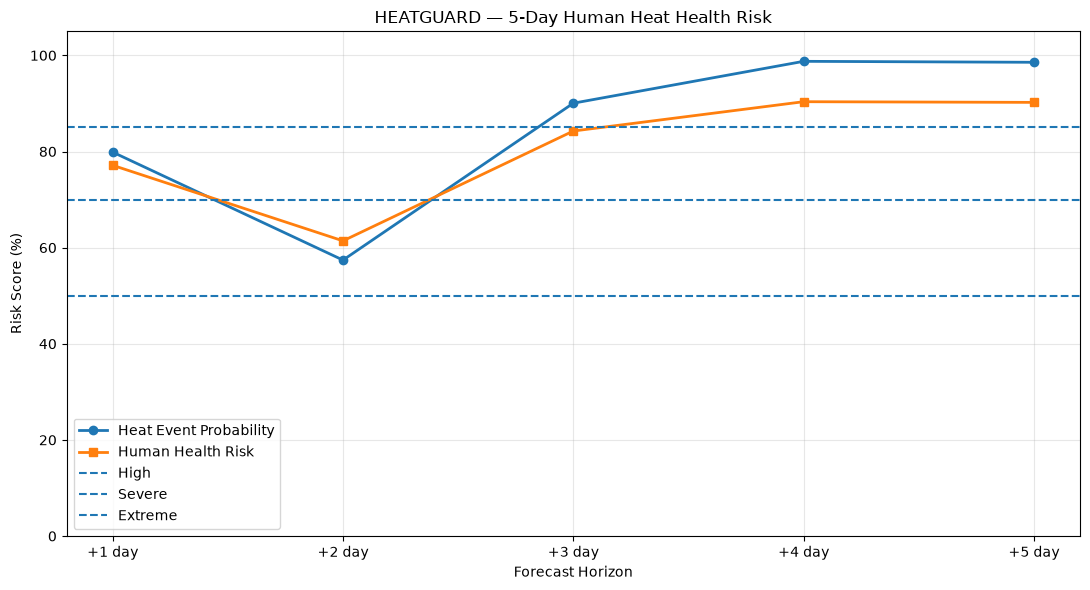

In [259]:
# ============================================================
# PHASE 6 — HUMAN HEALTH RISK VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(11, 6))

plt.plot(
    health_forecast["Forecast Day"],
    health_forecast["Risk Probability (%)"],
    marker="o",
    linewidth=2,
    label="Heat Event Probability"
)

plt.plot(
    health_forecast["Forecast Day"],
    health_forecast["human_health_risk"],
    marker="s",
    linewidth=2,
    label="Human Health Risk"
)

# Risk thresholds
plt.axhline(
    50,
    linestyle="--",
    label="High"
)

plt.axhline(
    70,
    linestyle="--",
    label="Severe"
)

plt.axhline(
    85,
    linestyle="--",
    label="Extreme"
)

plt.xlabel("Forecast Horizon")
plt.ylabel("Risk Score (%)")

plt.title(
    "HEATGUARD — 5-Day Human Heat Health Risk"
)

plt.ylim(0, 105)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.show()

In [260]:
# ============================================================
# PHASE 7 — GIS
# GENERATE LATEST 5-DAY RISK FOR ALL CITIES
# ============================================================

gis_predictions = []

cities_in_model = [
    "Kolkata",
    "Delhi",
    "Mumbai",
    "Ahmedabad",
    "Srinagar"
]

for city in cities_in_model:

    # Find latest available observation for this city
    city_rows = ml_data_encoded[
        ml_data_encoded[f"city_{city}"] == 1
    ].sort_values("date")

    latest_row = city_rows.iloc[-1]

    latest_X = (
        latest_row[feature_columns]
        .to_frame()
        .T
        .apply(pd.to_numeric, errors="coerce")
    )

    # Predict 1–5 days
    for days_ahead in range(1, 6):

        model = models[days_ahead]

        probability = (
            model.predict_proba(latest_X)[0, 1] * 100
        )

        gis_predictions.append({
            "city": city,
            "forecast_day": days_ahead,
            "risk_probability": probability
        })


gis_predictions = pd.DataFrame(gis_predictions)

gis_predictions["risk_probability"] = (
    gis_predictions["risk_probability"]
    .round(2)
)

gis_predictions

,city,forecast_day,risk_probability
0,Kolkata,1,79.870003
1,Kolkata,2,57.410000
2,Kolkata,3,90.050003
3,Kolkata,4,98.760002
4,Kolkata,5,98.559998
5,Delhi,1,99.760002
6,Delhi,2,99.430000
7,Delhi,3,79.120003
8,Delhi,4,97.970001
9,Delhi,5,99.519997


In [261]:
# ============================================================
# PEAK 5-DAY RISK FOR EACH CITY
# ============================================================

peak_risk = (
    gis_predictions
    .sort_values("risk_probability", ascending=False)
    .groupby("city")
    .first()
    .reset_index()
)

peak_risk

,city,forecast_day,risk_probability
0,Ahmedabad,3,98.639999
1,Delhi,1,99.760002
2,Kolkata,4,98.760002
3,Mumbai,3,96.800003
4,Srinagar,5,0.380000


In [262]:
# ============================================================
# PHASE 7 — CREATE GIS DATASET
# ============================================================

city_coordinates = pd.DataFrame({
    "city": [
        "Kolkata",
        "Delhi",
        "Mumbai",
        "Ahmedabad",
        "Srinagar"
    ],
    "latitude": [
        22.5726,
        28.6139,
        19.0760,
        23.0225,
        34.0837
    ],
    "longitude": [
        88.3639,
        77.2090,
        72.8777,
        72.5714,
        74.7973
    ]
})

gis_data = peak_risk.merge(
    city_coordinates,
    on="city",
    how="left"
)

gis_data = gis_data.merge(
    vulnerability[
        ["city", "vulnerability_score"]
    ],
    on="city",
    how="left"
)

gis_data

,city,forecast_day,risk_probability,latitude,longitude,vulnerability_score
0,Ahmedabad,3,98.639999,23.0225,72.5714,66.75
1,Delhi,1,99.760002,28.6139,77.2090,72.50
2,Kolkata,4,98.760002,22.5726,88.3639,70.75
3,Mumbai,3,96.800003,19.0760,72.8777,68.50
4,Srinagar,5,0.380000,34.0837,74.7973,46.75


In [263]:
# ============================================================
# PHASE 7 — GIS MAP
# ============================================================

!pip install folium -q

import folium

In [264]:
# ============================================================
# PHASE 7 — HEATGUARD GIS MAP
# COMPLETE + ROBUST VERSION
# ============================================================

import folium

# ------------------------------------------------------------
# 1. Make sure health risk exists
# ------------------------------------------------------------

gis_data["human_health_risk"] = (
    0.70 * gis_data["risk_probability"] +
    0.30 * gis_data["vulnerability_score"]
)

gis_data["human_health_risk"] = (
    gis_data["human_health_risk"]
    .clip(0, 100)
    .round(2)
)


# ------------------------------------------------------------
# 2. Warning classification
# ------------------------------------------------------------

def get_warning(score):

    if score < 25:
        return "LOW"

    elif score < 50:
        return "MODERATE"

    elif score < 70:
        return "HIGH"

    elif score < 85:
        return "SEVERE"

    else:
        return "EXTREME"


gis_data["warning_level"] = (
    gis_data["human_health_risk"]
    .apply(get_warning)
)


# ------------------------------------------------------------
# 3. Create India map
# ------------------------------------------------------------

heatguard_map = folium.Map(
    location=[22.5, 79.0],
    zoom_start=5,
    tiles="OpenStreetMap"
)


# ------------------------------------------------------------
# 4. Add city risk markers
# ------------------------------------------------------------

for _, row in gis_data.iterrows():

    # Marker colour
    if row["warning_level"] == "EXTREME":
        marker_color = "red"

    elif row["warning_level"] == "SEVERE":
        marker_color = "orange"

    elif row["warning_level"] == "HIGH":
        marker_color = "yellow"

    elif row["warning_level"] == "MODERATE":
        marker_color = "blue"

    else:
        marker_color = "green"


    # Popup information
    popup_html = f"""
    <div style="width:260px">

        <h3>🔥 HEATGUARD</h3>

        <b>City:</b> {row["city"]}<br><br>

        <b>Peak Forecast:</b>
        +{int(row["forecast_day"])} day<br>

        <b>Heat Probability:</b>
        {row["risk_probability"]:.2f}%<br>

        <b>Vulnerability:</b>
        {row["vulnerability_score"]:.2f}/100<br>

        <b>Human Health Risk:</b>
        {row["human_health_risk"]:.2f}/100<br>

        <b>Warning:</b>
        {row["warning_level"]}

    </div>
    """


    # Add marker
    folium.CircleMarker(
        location=[
            row["latitude"],
            row["longitude"]
        ],

        radius=14,

        color=marker_color,

        fill=True,

        fill_color=marker_color,

        fill_opacity=0.75,

        weight=2,

        popup=folium.Popup(
            popup_html,
            max_width=300
        ),

        tooltip=(
            f'{row["city"]} | '
            f'{row["warning_level"]} | '
            f'{row["human_health_risk"]:.1f}/100'
        )

    ).add_to(heatguard_map)


# ------------------------------------------------------------
# 5. Display map
# ------------------------------------------------------------

heatguard_map

In [265]:
# ============================================================
# SAVE HEATGUARD GIS MAP
# ============================================================

heatguard_map.save(
    "HEATGUARD_India_Heat_Risk_Map.html"
)

print("Map saved successfully!")

Map saved successfully!


In [266]:
# ============================================================
# PHASE 7 — HEATGUARD HYPERLOCAL GIS RISK MAP
# ADVANCED WARD/ZONE-READY VERSION
# ============================================================

!pip -q install folium branca

import folium
import numpy as np
import pandas as pd

from folium.plugins import HeatMap
from branca.colormap import LinearColormap
from folium.features import DivIcon


# ============================================================
# 1. ENSURE HEALTH RISK EXISTS
# ============================================================

gis_data["human_health_risk"] = (
    0.70 * gis_data["risk_probability"]
    + 0.30 * gis_data["vulnerability_score"]
)

gis_data["human_health_risk"] = (
    gis_data["human_health_risk"]
    .clip(0, 100)
    .round(2)
)


# ============================================================
# 2. WARNING CLASSIFICATION
# ============================================================

def get_warning(score):

    if score < 25:
        return "LOW"

    elif score < 50:
        return "MODERATE"

    elif score < 70:
        return "HIGH"

    elif score < 85:
        return "SEVERE"

    else:
        return "EXTREME"


gis_data["warning_level"] = (
    gis_data["human_health_risk"]
    .apply(get_warning)
)


# ============================================================
# 3. RISK COLOR FUNCTION
# ============================================================

def risk_color(score):

    if score < 25:
        return "#2ecc71"       # Green

    elif score < 50:
        return "#f1c40f"       # Yellow

    elif score < 70:
        return "#f39c12"       # Orange

    elif score < 85:
        return "#e74c3c"       # Red

    else:
        return "#8e0000"       # Dark Red


# ============================================================
# 4. CREATE BASE INDIA MAP
# ============================================================

heatguard_map = folium.Map(

    location=[22.5, 79.0],

    zoom_start=5,

    tiles=None,

    control_scale=True

)


# ============================================================
# 5. MULTIPLE BASE MAPS
# ============================================================

folium.TileLayer(
    "CartoDB positron",
    name="Light GIS",
    control=True
).add_to(heatguard_map)


folium.TileLayer(
    "CartoDB dark_matter",
    name="Dark Command Center",
    control=True
).add_to(heatguard_map)


folium.TileLayer(
    "OpenStreetMap",
    name="Street Map",
    control=True
).add_to(heatguard_map)


# ============================================================
# 6. CREATE RISK GRADIENT LEGEND
# ============================================================

gradient = LinearColormap(

    colors=[
        "#2ecc71",
        "#f1c40f",
        "#f39c12",
        "#e74c3c",
        "#8e0000"
    ],

    vmin=0,

    vmax=100,

    caption="HEATGUARD Human Health Risk Index"

)

gradient.add_to(heatguard_map)


# ============================================================
# 7. CREATE HYPERLOCAL ZONES
# ============================================================

# IMPORTANT:
# These are prototype hyperlocal zones.
# They are NOT official municipal ward boundaries.
#
# When official ward GeoJSON becomes available,
# replace this section with actual ward polygons.

zone_data = []


# 3 × 3 zone structure around each city
# Approximately 3 km spacing at Indian latitudes.

offsets = [

    (-0.03, -0.03),
    (-0.03,  0.00),
    (-0.03,  0.03),

    ( 0.00, -0.03),
    ( 0.00,  0.00),
    ( 0.00,  0.03),

    ( 0.03, -0.03),
    ( 0.03,  0.00),
    ( 0.03,  0.03)

]


for _, city in gis_data.iterrows():

    city_name = city["city"]

    base_lat = city["latitude"]
    base_lon = city["longitude"]

    base_risk = float(city["human_health_risk"])

    base_probability = float(
        city["risk_probability"]
    )

    vulnerability = float(
        city["vulnerability_score"]
    )

    for i, (lat_offset, lon_offset) in enumerate(offsets):

        # Spatial variation.
        # This prevents the map from appearing as
        # nine identical cells.

        spatial_modifier = (

            5 * np.sin(i * 1.7)

            + 2.5 * np.cos(i * 0.9)

        )

        zone_risk = np.clip(

            base_risk + spatial_modifier,

            0,

            100

        )

        zone_probability = np.clip(

            base_probability
            + spatial_modifier * 0.7,

            0,

            100

        )

        zone_id = f"{city_name}-Z{i+1:02d}"

        zone_data.append({

            "city": city_name,

            "zone_id": zone_id,

            "latitude":
                base_lat + lat_offset,

            "longitude":
                base_lon + lon_offset,

            "human_health_risk":
                round(zone_risk, 2),

            "risk_probability":
                round(zone_probability, 2),

            "vulnerability_score":
                vulnerability,

            "warning_level":
                get_warning(zone_risk)

        })


zones_df = pd.DataFrame(zone_data)


# ============================================================
# 8. CREATE POLYGON FOR EACH HYPERLOCAL ZONE
# ============================================================

zone_layer = folium.FeatureGroup(

    name="Hyperlocal Risk Zones",

    show=True

)

zone_size = 0.015


for _, row in zones_df.iterrows():

    lat = row["latitude"]
    lon = row["longitude"]

    polygon = [

        [lat - zone_size, lon - zone_size],

        [lat - zone_size, lon + zone_size],

        [lat + zone_size, lon + zone_size],

        [lat + zone_size, lon - zone_size]

    ]

    risk = row["human_health_risk"]

    color = risk_color(risk)


    # --------------------------------------------------------
    # POPUP
    # --------------------------------------------------------

    popup_html = f"""

    <div style="
        width:310px;
        font-family:Arial;
        line-height:1.5;
    ">

        <h2 style="margin-bottom:5px;">
            🔥 HEATGUARD
        </h2>

        <h3 style="margin-top:0;">
            {row["city"]} — {row["zone_id"]}
        </h3>

        <hr>

        <b>Heat Probability:</b>
        {row["risk_probability"]:.1f}%

        <br>

        <b>Vulnerability:</b>
        {row["vulnerability_score"]:.1f}/100

        <br>

        <b>Human Health Risk:</b>
        {risk:.1f}/100

        <br>

        <b>Warning Level:</b>
        <span style="
            font-weight:bold;
            color:{color};
        ">
            {row["warning_level"]}
        </span>

        <hr>

        <b>Recommended Action:</b>

        <br>

        {"🚨 Activate heat action plan and cooling resources"
        if row["warning_level"] == "EXTREME"

        else "⚠️ Increase monitoring and hydration advisories"
        if row["warning_level"] in ["SEVERE", "HIGH"]

        else "ℹ️ Continue routine monitoring"}

    </div>

    """


    folium.Polygon(

        locations=polygon,

        color=color,

        weight=1.5,

        fill=True,

        fill_color=color,

        fill_opacity=0.45,

        popup=folium.Popup(

            popup_html,

            max_width=350

        ),

        tooltip=(

            f"🔥 {row['zone_id']} | "

            f"{row['warning_level']} | "

            f"Health Risk: "

            f"{risk:.1f}/100"

        )

    ).add_to(zone_layer)


zone_layer.add_to(heatguard_map)


# ============================================================
# 9. HEAT RISK INTENSITY SURFACE
# ============================================================

heat_layer = folium.FeatureGroup(

    name="Heat Risk Intensity",

    show=True

)


heat_points = [

    [

        row["latitude"],

        row["longitude"],

        row["human_health_risk"] / 100

    ]

    for _, row in zones_df.iterrows()

]


HeatMap(

    heat_points,

    min_opacity=0.25,

    max_zoom=8,

    radius=35,

    blur=30,

    gradient={

        0.00: "#2ecc71",

        0.25: "#f1c40f",

        0.50: "#f39c12",

        0.70: "#e74c3c",

        0.85: "#c0392b",

        1.00: "#8e0000"

    }

).add_to(heat_layer)


heat_layer.add_to(heatguard_map)


# ============================================================
# 10. CITY COMMAND CENTRE MARKERS
# ============================================================

city_layer = folium.FeatureGroup(

    name="City Risk Centres",

    show=True

)


for _, row in gis_data.iterrows():

    color = risk_color(
        row["human_health_risk"]
    )


    # --------------------------------------------------------
    # CITY POPUP
    # --------------------------------------------------------

    popup_html = f"""

    <div style="
        width:320px;
        font-family:Arial;
    ">

        <h2>🔥 HEATGUARD</h2>

        <h3>{row["city"]}</h3>

        <hr>

        <b>Peak Forecast:</b>
        +{int(row["forecast_day"])} day

        <br><br>

        <b>Heat Probability:</b>
        {row["risk_probability"]:.2f}%

        <br>

        <b>Vulnerability:</b>
        {row["vulnerability_score"]:.2f}/100

        <br>

        <b>Human Health Risk:</b>
        {row["human_health_risk"]:.2f}/100

        <br>

        <b>Warning:</b>

        <span style="
            color:{color};
            font-weight:bold;
        ">

            {row["warning_level"]}

        </span>

        <hr>

        <b>GIS Status:</b>
        Hyperlocal monitoring active

    </div>

    """


    # --------------------------------------------------------
    # OUTER RISK RING
    # --------------------------------------------------------

    folium.Circle(

        location=[
            row["latitude"],
            row["longitude"]
        ],

        radius=7000,

        color=color,

        fill=False,

        weight=3,

        opacity=0.55

    ).add_to(city_layer)


    # --------------------------------------------------------
    # CENTRAL MARKER
    # --------------------------------------------------------

    folium.CircleMarker(

        location=[
            row["latitude"],
            row["longitude"]
        ],

        radius=11,

        color="white",

        weight=2,

        fill=True,

        fill_color=color,

        fill_opacity=1,

        popup=folium.Popup(

            popup_html,

            max_width=360

        ),

        tooltip=(

            f"🔥 {row['city']} | "

            f"{row['warning_level']} | "

            f"{row['human_health_risk']:.1f}/100"

        )

    ).add_to(city_layer)


    # --------------------------------------------------------
    # CITY LABEL
    # --------------------------------------------------------

    folium.Marker(

        location=[

            row["latitude"] + 0.045,

            row["longitude"]

        ],

        icon=DivIcon(

            html=f"""

            <div style="

                font-size:12px;

                font-weight:bold;

                color:#222;

                background:white;

                padding:3px 6px;

                border-radius:5px;

                border:1px solid #555;

                box-shadow:0 1px 4px rgba(0,0,0,0.3);

                white-space:nowrap;

            ">

                {row["city"]}

            </div>

            """

        )

    ).add_to(city_layer)


city_layer.add_to(heatguard_map)


# ============================================================
# 11. EXTREME-HOTSPOT LAYER
# ============================================================

hotspot_layer = folium.FeatureGroup(

    name="Critical Hotspots",

    show=True

)


critical_zones = zones_df[

    zones_df["human_health_risk"] >= 70

]


for _, row in critical_zones.iterrows():

    folium.CircleMarker(

        location=[

            row["latitude"],

            row["longitude"]

        ],

        radius=5,

        color="#ffffff",

        fill=True,

        fill_color="#8e0000",

        fill_opacity=1,

        weight=1,

        tooltip=(

            f"🚨 HOTSPOT | "

            f"{row['zone_id']} | "

            f"{row['human_health_risk']:.1f}/100"

        )

    ).add_to(hotspot_layer)


hotspot_layer.add_to(heatguard_map)


# ============================================================
# 12. ADD INFORMATION PANEL
# ============================================================

info_html = """

<div style="

position: fixed;

bottom: 25px;

left: 25px;

z-index:9999;

background:white;

padding:12px 16px;

border-radius:10px;

box-shadow:0 2px 10px rgba(0,0,0,0.25);

font-family:Arial;

font-size:12px;

">

<b style="font-size:15px;">
🔥 HEATGUARD
</b>

<br>

Human Thermal Stress Intelligence

<hr>

<b>Map Layers</b>

<br>
🟥 Critical / Extreme

<br>
🟧 Severe

<br>
🟨 High / Moderate

<br>
🟩 Low

<br><br>

<b>Spatial Resolution:</b>
Hyperlocal Prototype Zones

</div>

"""


heatguard_map.get_root().html.add_child(

    folium.Element(info_html)

)


# ============================================================
# 13. LAYER CONTROL
# ============================================================

folium.LayerControl(

    collapsed=False

).add_to(heatguard_map)


# ============================================================
# 14. FULLSCREEN CONTROL
# ============================================================

from folium.plugins import Fullscreen

Fullscreen(

    position="topright",

    title="Open Fullscreen",

    title_cancel="Exit Fullscreen",

    force_separate_button=True

).add_to(heatguard_map)


# ============================================================
# 15. FINAL DISPLAY
# ============================================================

heatguard_map